# 🦅 Anatomy of a Speedup: EAGLE-3 Speculative Decoding on Qwen3

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin) · a measured walkthrough of [EAGLE-3](https://arxiv.org/abs/2503.01840) (Yuhui Li, Fangyun Wei, Chao Zhang, Hongyang Zhang — NeurIPS 2025)*

A language model writes one token at a time, and every token costs a full pass through all of its weights. Speculative decoding works around that: a small draft model proposes several next tokens in advance, the big target model checks them all in a single pass and keeps the ones that match its own choice. The output text is the same — only getting it becomes faster.

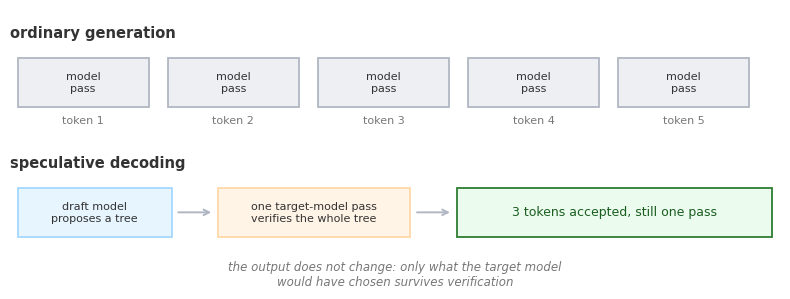

In [1]:
# --- One picture that explains the method ---------------------------------------
import os
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

C_INK = "#333333"
KAGGLE_BODY_PX = 730          # body width of a rendered Kaggle notebook

def finish(name):
    """Show the figure and save it at the exact size the reader will see."""
    os.makedirs("/kaggle/working/figs", exist_ok=True)
    plt.tight_layout()
    w_in = plt.gcf().get_size_inches()[0]
    plt.savefig(f"/kaggle/working/figs/{name}.png",
                dpi=KAGGLE_BODY_PX / w_in, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(8.0, 3.1))
ax.set_xlim(0, 20); ax.set_ylim(0, 6.4); ax.axis("off")

def cell(x, y, w, h, text, fc, ec, fs=8.5, tc="#333333"):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.3, zorder=2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs, color=tc, zorder=3)

ax.text(0, 5.7, "ordinary generation", fontsize=10.5, color=C_INK, weight="bold")
for k in range(5):
    cell(0.2 + k*3.9, 4.0, 3.4, 1.2, "model\npass", "#EDEFF3", "#B0B7C3", fs=8)
    ax.text(0.2 + k*3.9 + 1.7, 3.6, f"token {k+1}", ha="center", fontsize=8, color="#777")

ax.text(0, 2.5, "speculative decoding", fontsize=10.5, color=C_INK, weight="bold")
cell(0.2, 0.8, 4.0, 1.2, "draft model\nproposes a tree", "#E7F5FF", "#A5D8FF", fs=8)
cell(5.4, 0.8, 5.0, 1.2, "one target-model pass\nverifies the whole tree",
     "#FFF4E6", "#FFD8A8", fs=8)
cell(11.6, 0.8, 8.2, 1.2, "3 tokens accepted, still one pass",
     "#EBFBEE", "#2E7D32", fs=9, tc="#1B5E20")
for x0, x1 in ((4.3, 5.3), (10.5, 11.5)):
    ax.annotate("", xy=(x1, 1.4), xytext=(x0, 1.4),
                arrowprops=dict(arrowstyle="->", color="#B0B7C3", lw=1.4))
ax.text(10.0, 0.2, "the output does not change: only what the target model\n"
                   "would have chosen survives verification",
        ha="center", va="top", fontsize=8.5, color="#777", style="italic")
finish("hero")


Top row: ordinary generation, five passes for five tokens. Bottom row: one target-model pass returns three. How much of a win that is comes down to one thing: how often the draft model is right.

The paper reports up to 6.5× on its own setups. I re-ran the method on Qwen3-1.7B with a free Kaggle T4: about 2.5× on math and code, about 2.3× across the paper's four English benchmarks — and about 0.95× on Russian prompts, where the method made generation slower than the plain loop. Both outcomes follow from a single formula for the speedup. I derive it in [§1](#s1), and every section after that pins down one of its terms.

*Run All needs a T4 GPU. Weights load from the attached Kaggle models — internet is used only for one pip install and cloning the EAGLE repo. The full run takes about 35 minutes, or about 10 with `QUICK = True`.*

### What's in here

- EAGLE-3 running on Qwen3-1.7B with the official SafeAILab code and attached Kaggle weights — [§4](#s4).
- Vanilla autoregressive vs EAGLE-3, measured on five prompt sets with equal work per engine — [§5](#s5).
- The draft tree built, dissected and timed: shape ablation, cycle phases, losslessness checks — [§6](#s6)–[§10](#s10).
- The same protocol re-run on a target twice the size, Qwen3-4B — [§11](#scaling).

### What you'll learn

1. Why verifying a whole draft tree costs about as much as generating a single token — measured, not quoted from a spec sheet.
2. What an ordinary generation step really costs: four times the theoretical minimum, and why part of the method's win is amortizing that overhead.
3. What the draft tree looks like from the inside, and how much branching adds over a plain chain.
4. Which tree shape is optimal — one knob at a time, with repeats, instead of turning three knobs at once.
5. How to check the method doesn't change the output: token-by-token under greedy decoding, statistically under sampling.
6. When the method hurts: off the draft head's training domain it loses to the plain loop.
7. Whether a bigger target really amortizes the draft head better — the common intuition, put to a measurement on Qwen3-4B.

### Contents

- [0. Run parameters](#s0)
- [1. The arithmetic of decoding](#s1)
- [2. The KV cache: what memory costs, and why a tree can live there](#s2)
- [3. What EAGLE-3 actually changes — and what shows up in the weights](#s3)
- [4. Three ways to generate with one model](#s4)
- [5. Benchmarks from the paper](#s5)
- [6. The draft tree: anatomy of a single step](#s6)
- [7. Tree shape: two one-knob sweeps](#s7)
- [8. Where the cycle spends its time](#s8)
- [9. Temperature: where the method's main guarantee is tested](#s9)
- [10. Matching plain generation at T = 0](#s10)
- [11. The same method, a bigger target](#scaling)
- [12. What didn't work](#dead-ends)
- [13. Takeaways](#takeaways)
- [14. Run it yourself, further reading, licenses](#use-it)

<a id="s0"></a>
## 0. Run parameters

The four lines below are everything you touch when forking this notebook to try another combination. The rest assembles itself around them: the weights load, and the prompt sets, tables and figures rebuild with the same settings.

- `BASE_MODEL` — the target model whose generation is being sped up. Resolved from the attached Kaggle model, with a Hub fallback off-Kaggle.
- `EA_MODEL` — the draft head trained for this exact target. Ready-made heads for other targets are listed in the EAGLE README, linked from [§14](#use-it).
- `QUICK` — a ~10-minute run instead of ~35: fewer questions per set, fewer repeats per measurement, and the scaling probe ([§11](#scaling)) is skipped entirely — it needs a second pair of models loaded.
- `LANG_SET` — the prompt set treated as out-of-domain for the draft head. It must match a key of the `BENCH` dict in [§5](#s5) (add your own set there); [§5](#s5) uses it to show what happens when the head was trained on different data.


In [2]:
import glob, os

def attached(pattern, hub_id):
    """Weights come from attached Kaggle models; fall back to the Hub elsewhere."""
    hits = sorted(glob.glob(os.path.join(pattern, "config.json")))
    return os.path.dirname(hits[-1]) if hits else hub_id

BASE_MODEL = attached("/kaggle/input/models/qwen-lm/qwen-3/transformers/1.7b/*",
                      "Qwen/Qwen3-1.7B")
EA_MODEL   = attached("/kaggle/input/models/georgymamarin/qwen3-1-7b-eagle3-draft-head/pytorch/fp16/*",
                      "AngelSlim/Qwen3-1.7B_eagle3")
QUICK      = False
LANG_SET   = "Russian"
print(BASE_MODEL); print(EA_MODEL)   # confirm the weights resolved to /kaggle/input


/kaggle/input/models/qwen-lm/qwen-3/transformers/1.7b/1
/kaggle/input/models/georgymamarin/qwen3-1-7b-eagle3-draft-head/pytorch/fp16/1


The cell below prepares the environment: installs the pinned `transformers`, clones the EAGLE repository at a fixed commit and checks the runner actually got the GPU everything here was measured on. It also prints versions: Kaggle's base image updates silently and breaks old notebooks.

In [3]:
# --- Environment: pins, repo clone, imports --------------------------------------
import os, sys, gc, time, json, math, random, subprocess
from collections import Counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"       # one T4, even when the runner hands out T4 x2
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# weight-download progress bars write to stderr and leave a blank band on the page
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

EAGLE_COMMIT = "cb7e0841fe0c206c6ed74a197ad5e2a1f13f5a2b"   # 19.02.2026
TRANSFORMERS_PIN = "4.53.1"     # the EAGLE commit needs 4.53.1; Kaggle preinstalls 5.x

import warnings
warnings.filterwarnings("ignore")

def sh(cmd, quiet=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if not quiet:
        out = (r.stdout + r.stderr).strip()
        if out:
            print(out[-1200:])

# --progress-bar off: otherwise the notebook opens with download bars
sh(f"pip install -q --progress-bar off 'transformers=={TRANSFORMERS_PIN}'")
if not os.path.exists("/kaggle/working/EAGLE"):
    sh("git clone -q https://github.com/SafeAILab/EAGLE.git /kaggle/working/EAGLE")
    sh(f"cd /kaggle/working/EAGLE && git checkout -q {EAGLE_COMMIT}")

# Qwen3-4B's attention is wider than its hidden size (32 heads x 128 = 4096 vs 2560).
# The official draft code derives head width from hidden size alone and cannot load
# that head; honor config.head_dim instead. A no-op for heads where the two coincide
# (the 1.7B pair) — and the only modification to the official code in this notebook.
_p = "/kaggle/working/EAGLE/eagle/model/cnets.py"
_src = open(_p).read()
_src = _src.replace(
    "self.head_dim = self.hidden_size // self.num_heads",
    'self.head_dim = getattr(config, "head_dim", None) or self.hidden_size // self.num_heads')
_src = _src.replace(
    "if (self.head_dim * self.num_heads) != self.hidden_size:", "if False:")
_src = _src.replace(
    "attn_output.reshape(bsz, q_len, self.hidden_size)",
    "attn_output.reshape(bsz, q_len, self.num_heads * self.head_dim)")
open(_p, "w").write(_src)
sys.path.insert(0, "/kaggle/working/EAGLE")

import torch, transformers
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def seed_everything(seed=0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(0)

assert torch.cuda.is_available(), "Needs a GPU runner: Settings -> Accelerator -> GPU T4 x2"
CC = torch.cuda.get_device_capability(0)
assert CC >= (7, 0), (f"GPU {torch.cuda.get_device_name(0)} (sm_{CC[0]}{CC[1]}) is not supported "
                      "by the preinstalled torch. Pick a T4.")
print(f"GPU: {torch.cuda.get_device_name(0)} (sm_{CC[0]}{CC[1]})")
print(f"torch {torch.__version__} | transformers {transformers.__version__}")

from eagle.model.ea_model import EaModel
print("EAGLE imported, commit", EAGLE_COMMIT[:12])

# --- rest of the palette; C_INK and finish are defined above, next to the hero ---
C_EAGLE, C_NAIVE, C_HF = "#F58518", "#4C78A8", "#8A93A6"
C_GRID, C_OK = "#C4CAD4", "#2E7D32"

# Environment snapshot, because the base image drifts underneath old notebooks
import platform
print(f"python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__}")

# Hardware datasheet numbers: needed for the roofline in §1
GPU_BW_GBS   = 320.0     # Tesla T4, GB/s (datasheet)
GPU_FP16_TFLOPS = 65.0   # Tesla T4, fp16 TFLOPS with tensor cores


GPU: Tesla T4 (sm_75)
torch 2.10.0+cu128 | transformers 4.53.1
EAGLE imported, commit cb7e0841fe0c
python 3.12.13 | numpy 2.0.2 | pandas 2.3.3


<a id="s1"></a>
## 1. The arithmetic of decoding

Autoregressive generation yields one token per pass, and each pass makes the GPU read every weight of the model for the sake of that one token. That comes to roughly one operation per byte read, while the card is built for about 200:

$$I_{\mathrm{decode}} = \frac{2\ \mathrm{op/param}}{2\ \mathrm{byte/param}} = 1,
\qquad
I_{\mathrm{T4}} = \frac{65\ \mathrm{TFLOPS}}{320\ \mathrm{GB/s}} \approx 200$$

On the left, the arithmetic intensity of fp16 decoding; on the right, the T4's datasheet balance. Decoding sits two hundred times below the break-even point: a step takes exactly as long as pumping the weights through the memory bus, and the compute units idle. Generation is memory-bound, not compute-bound.

The key consequence: if step time is set by reading weights, then processing several tokens instead of one barely changes the cost, because the weights are read once either way. Verifying k drafts should be about as cheap as generating a single token.

That claim is usually quoted. Here it gets measured — along with the boundary where "almost free" ends.

Loading the target model and the draft head. Both are small: the target is 3.2 GB in half precision, the head another 0.27 GB, so everything fits comfortably into the T4's 16 GB.

In [4]:
# --- Model load (needed for the roofline and for everything after) ---------------
t0 = time.time()
model = EaModel.from_pretrained(
    use_eagle3=True,
    base_model_path=BASE_MODEL,
    ea_model_path=EA_MODEL,
    total_token=60, depth=7, top_k=10,      # starting shape; §7 justifies the final pick
    torch_dtype=torch.float16,
    device_map={"": 0},
).eval()
tok = model.get_tokenizer()
cfg = model.base_model.config
print(f"loaded in {time.time()-t0:.0f} s")

N_TARGET = sum(p.numel() for p in model.base_model.parameters())
N_DRAFT  = sum(p.numel() for n, p in model.ea_layer.named_parameters()
               if "embed_tokens" not in n)
L = cfg.num_hidden_layers
print(f"target model: {N_TARGET/1e9:.2f}B params, {L} layers, "
      f"{N_TARGET*2/2**30:.2f} GB in fp16")
print(f"draft head: {N_DRAFT/1e6:.0f}M ({100*N_DRAFT/N_TARGET:.1f}% of the target)")

def timed(fn, *a, **k):
    torch.cuda.synchronize()
    t = time.perf_counter()
    out = fn(*a, **k)
    torch.cuda.synchronize()
    return out, time.perf_counter() - t

def plain_forward(ids):
    """A target-model pass without the tree mask.

    After eagenerate, base_model.model keeps the tree_mask of the last tree,
    and a plain pass of a different length trips over it. Clear it explicitly.
    """
    model.base_model.model.tree_mask = None
    return model.base_model(ids)



loaded in 36 s
target model: 1.72B params, 28 layers, 3.20 GB in fp16
draft head: 137M (8.0% of the target)


First measurement: how long one target-model pass takes when it is fed several tokens at once instead of one. If the reasoning above holds, the curve should be flat — the weights are read once no matter how many tokens are processed.

In [5]:
# --- Measurement 1: cost of one target pass vs tokens processed -------------------
# A direct test of the "tree is almost free" claim: if decode is memory-bound,
# the curve must stay FLAT while the weights dominate the compute.
SIZES = [1, 2, 4, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]
REP = 5 if QUICK else 11

roof = {}
with torch.no_grad():
    for n in (1, 8):                                   # warm up both shapes
        plain_forward(torch.ones(1, n, dtype=torch.long).cuda())
    for n in SIZES:
        ids = torch.randint(0, 100_000, (1, n)).cuda()
        for _ in range(3):
            plain_forward(ids)
        ts = [timed(plain_forward, ids)[1] * 1000 for _ in range(REP)]
        roof[n] = float(np.median(ts))

step_ms = roof[1]
weights_bytes = N_TARGET * 2                                   # fp16
predicted_ms = weights_bytes / (GPU_BW_GBS * 1e9) * 1e3        # bytes / (B/s) -> ms
mbu = 100 * predicted_ms / step_ms                             # share of peak bandwidth

print(f"{'tokens':>8} {'ms':>7} {'ms/token':>9} {'vs n=1':>7}")
for n in SIZES:
    print(f"{n:8d} {roof[n]:7.1f} {roof[n]/n:9.3f} {roof[n]/step_ms:6.2f}x")

free_upto = max(n for n in SIZES if roof[n] < 1.25 * step_ms)
print(f"\none token: {step_ms:.1f} ms")
print(f"roofline prediction (weights read only): {predicted_ms:.1f} ms")
print(f"=> memory-bandwidth utilization (MBU): {mbu:.0f}%")
print(f"=> a pass gets less than 25% dearer all the way to {free_upto} tokens")


  tokens      ms  ms/token  vs n=1
       1    48.6    48.617   1.00x
       2    50.3    25.158   1.03x
       4    50.2    12.562   1.03x
       8    52.0     6.503   1.07x
      16    52.2     3.265   1.07x
      24    51.1     2.127   1.05x
      32    46.7     1.458   0.96x
      48    48.2     1.005   0.99x
      64    47.7     0.745   0.98x
      96    47.3     0.493   0.97x
     128    47.4     0.370   0.97x
     192    48.8     0.254   1.00x
     256    61.9     0.242   1.27x
     384    86.5     0.225   1.78x
     512   121.0     0.236   2.49x

one token: 48.6 ms
roofline prediction (weights read only): 10.8 ms
=> memory-bandwidth utilization (MBU): 22%
=> a pass gets less than 25% dearer all the way to 192 tokens


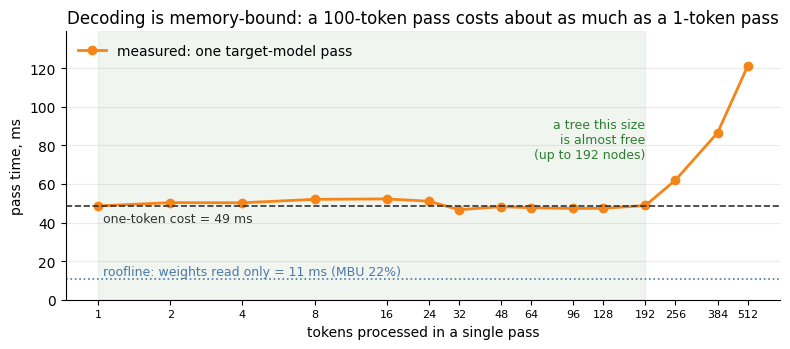

In [6]:
# --- Figure: pass cost vs number of tokens ---------------------------------------
xs = np.array(SIZES, dtype=float)
ys = np.array([roof[n] for n in SIZES])

fig, ax = plt.subplots(figsize=(8.0, 3.6))
ax.plot(xs, ys, "o-", color=C_EAGLE, lw=2, ms=6, label="measured: one target-model pass")
ax.axhline(step_ms, color=C_INK, lw=1.2, ls="--")
# The label goes UNDER the dashed line: the flat part of the curve sits above it,
# while the band between the dashes and the roofline stays empty for any data.
ax.text(1.05, step_ms - (step_ms - predicted_ms) * 0.08,
        f"one-token cost = {step_ms:.0f} ms",
        fontsize=9, color=C_INK, va="top")
ax.axhline(predicted_ms, color=C_NAIVE, lw=1.2, ls=":")
ax.text(1.05, predicted_ms * 1.06,
        f"roofline: weights read only = {predicted_ms:.0f} ms (MBU {mbu:.0f}%)",
        fontsize=9, color=C_NAIVE, va="bottom")
ax.axvspan(1, free_upto, color=C_OK, alpha=0.07)
# Anchor the note above the flat region, not at a fraction of the maximum: the
# maximum tracks the right tail, the flat region tracks step time, and on other
# hardware the two drift apart.
flat_max = ys[xs <= free_upto].max()
ax.text(free_upto, flat_max + (ys.max() - flat_max) * 0.45,
        f"  a tree this size\n  is almost free\n  (up to {free_upto} nodes)",
        fontsize=9, color=C_OK, ha="right", va="center")
ax.set_xscale("log", base=2); ax.set_xticks(SIZES)
ax.set_xticklabels([str(s) for s in SIZES], fontsize=8)
ax.set_xlabel("tokens processed in a single pass")
ax.set_ylabel("pass time, ms")
ax.set_ylim(0, ys.max() * 1.15)
ax.set_title("Decoding is memory-bound: a 100-token pass costs about as much as a 1-token pass")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
finish("roofline")


> **Takeaway.** The curve stays flat to just under 192 tokens: a 100-token pass costs about as much as a 1-token pass. That headroom is what speculative decoding runs on. The second thing to notice is the gap to the dashed line: an ordinary step costs four times the theoretical minimum, so the plain loop has slack of its own — and part of the upcoming speedup will come from there.

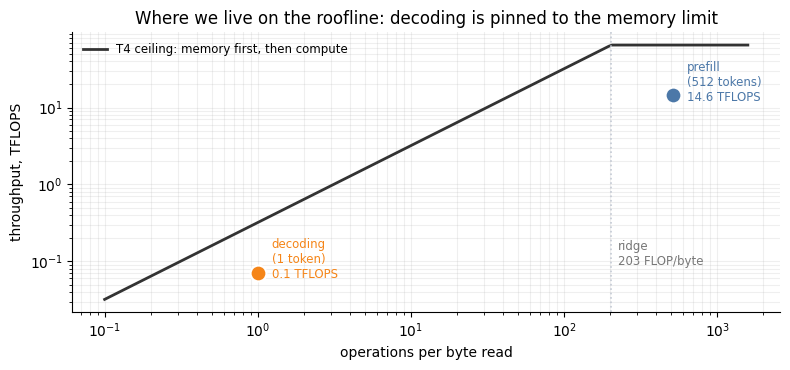

decoding (1 token)     ops per byte     1.0 |   0.1 TFLOPS of 65
prefill (512 tokens)   ops per byte   512.0 |  14.6 TFLOPS of 65


In [7]:
# --- The classic roofline with our two operating points ---------------------------
# Computed from measurements: operations per byte read, and the throughput we
# actually get in two regimes — decoding (1 token) and prefill (512 tokens).
flops_per_token = 2 * N_TARGET                      # multiply-accumulate = 2 ops
bytes_weights   = N_TARGET * 2                      # fp16

points = {}
for n, label in ((1, "decoding\n(1 token)"), (512, "prefill\n(512 tokens)")):
    sec = roof[n] / 1000
    points[label] = dict(
        intensity=flops_per_token * n / bytes_weights,   # operations per byte read
        achieved=flops_per_token * n / sec / 1e12)       # TFLOPS

ridge = GPU_FP16_TFLOPS * 1e12 / (GPU_BW_GBS * 1e9)      # roofline ridge point
xs_r = np.logspace(-1, 3.2, 200)
roof_y = np.minimum(xs_r * GPU_BW_GBS * 1e9 / 1e12, GPU_FP16_TFLOPS)

fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.plot(xs_r, roof_y, color=C_INK, lw=2, label="T4 ceiling: memory first, then compute")
ax.axvline(ridge, color=C_GRID, lw=1.2, ls=":")
ax.text(ridge * 1.1, 0.09, f"ridge\n{ridge:.0f} FLOP/byte", fontsize=8.5, color="#777")
for (label, p), col in zip(points.items(), (C_EAGLE, C_NAIVE)):
    ax.scatter([p["intensity"]], [p["achieved"]], s=130, color=col, zorder=5,
               edgecolor="white", linewidth=1.5)
    ax.annotate(f"{label}\n{p['achieved']:.1f} TFLOPS", (p["intensity"], p["achieved"]),
                textcoords="offset points", xytext=(10, -4), fontsize=8.5, color=col)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("operations per byte read")
ax.set_ylabel("throughput, TFLOPS")
ax.set_title("Where we live on the roofline: decoding is pinned to the memory limit")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2, which="both")
finish("roofline_diagram")

for label, p in points.items():
    print(f"{label.replace(chr(10), ' '):22s} ops per byte {p['intensity']:7.1f} | "
          f"{p['achieved']:5.1f} TFLOPS of {GPU_FP16_TFLOPS:.0f}")


> **Takeaway.** Decoding a single token lives on the left of the diagram, where throughput is capped by the memory bus and the compute units idle. Prefill at 512 tokens sits two orders of magnitude to the right, up against a different ceiling. Speculative decoding pushes the generation step rightward: more useful work for the same bytes read.

### The formula this whole walkthrough reduces to

**Acceptance length τ** is the average number of tokens a cycle yields per target-model pass: the accepted drafts plus the bonus token, so in the code it is `accept_length` + 1. Plain generation has τ = 1 by definition: one pass, one token.

The gain then reads:

$$S \;\approx\; \frac{\tau \cdot t_{\mathrm{step}}}{t_{\mathrm{verify}} + (d+1) \cdot t_{\mathrm{draft}}}$$

Notation:

- $S$ — speedup over plain generation;
- $\tau$ — acceptance length;
- $d$ — tree depth;
- $t_{\mathrm{step}}$ — time of an ordinary generation step;
- $t_{\mathrm{verify}}$ — time to verify the whole tree in one target-model pass;
- $t_{\mathrm{draft}}$ — time of one draft-model step.

The numerator is what a cycle brings in; the denominator is what it costs. The rest of the notebook measures each term separately: $t_{\mathrm{verify}}$ here and in [§8](#s8), $t_{\mathrm{draft}}$ in [§7](#s7) and [§8](#s8), $\tau$ in [§5](#s5). Every result below plugs back into this formula, including the one where the speedup lands under 1.


<div style="background-color:#fff4e6;border:2px solid #ffd8a8;border-radius:6px;padding:14px 16px;color:#111;font-size:15px">
<strong>The baseline.</strong> The measured step costs about four times the
roofline prediction: the memory bus runs at roughly a quarter of its bandwidth. The difference is
implementation overhead — attention without flash kernels, op-by-op CUDA launches from Python, no
CUDA graphs. Speculative decoding divides that overhead by τ accepted tokens, so <em>part</em> of the
speedup measured below amortizes the baseline's inefficiency rather than beating the memory wall.
On a tuned stack (vLLM, SGLang, CUDA graphs) an ordinary step sits closer to the memory limit and
speculation gains less: independent vLLM measurements report 1.3–2× where the authors' own
frameworks show 4–6× (["Performance or Illusion?", 2601.11580](https://arxiv.org/abs/2601.11580)).
<br><br>
One more boundary, without which the numbers read wrong. Everything measured here is latency at
batch = 1. Production cares about throughput, and that picture is different: at a large batch the
compute units are busy anyway, nothing is left to verify drafts with, and the gain collapses. The
paper itself shows this: 4–6× at batch = 1 against 1.38× in SGLang at batch 64. Speculative
decoding treats decode and decode only — prefill lives further right on the roofline and needs no
treatment.
</div>

<a id="s2"></a>
## 2. The KV cache: what memory costs, and why a tree can live there

The measurement above showed that a tree gets verified almost for free. What remains is where that tree lives between steps, and why it can live there at all.

Without an attention cache, generation would be quadratic: every new token would recompute keys and values for the whole prefix. The KV cache stores them and makes a step linear in context length. The price is memory, and it can be counted exactly.

For this model: 28 layers, 8 KV heads against 16 attention heads (GQA, twice as frugal as full attention), head size 128, 2 tensors (K and V), 2 bytes per number.

Speculative decoding adds a requirement plain generation does not have. One pass verifies a whole tree, but only one path in it gets accepted. So the cache must do three things: let each node attend only to its ancestors (**tree attention** — a mask, not the usual causal one), hold K and V for every node of the tree at once, and, after verification, keep just the winning path, dropping the other branches without any recompute.

EAGLE does this with no allocations in the loop: a buffer for the whole context is allocated once (`initialize_past_key_values`), and when a candidate is accepted its positions are copied into place inside that same buffer (`dst.copy_(tgt)` in `update_inference_inputs`), after which the length pointer advances. Correctness rests on one fact: each node's K and V were computed against its ancestors only, so for the accepted path they are exactly what plain sequential decoding would have produced. Rejected branches leave no trace.

Counting what the cache costs on this model, and how much of it a draft tree occupies.

In [8]:
# --- Measurement 2: KV-cache arithmetic ------------------------------------------
kv_per_token = 2 * L * cfg.num_key_value_heads * cfg.head_dim * 2      # K and V, fp16
weights_gb = N_TARGET * 2 / 2**30

print(f"layers {L} | KV heads {cfg.num_key_value_heads} (attention heads {cfg.num_attention_heads}, "
      f"i.e. GQA x{cfg.num_attention_heads // cfg.num_key_value_heads}) | head_dim {cfg.head_dim}")
print(f"KV per token: {kv_per_token/1024:.0f} KB")
for ctx in (512, 2048, 8192, 40960):
    print(f"  context {ctx:6d} -> {kv_per_token*ctx/2**20:8.0f} MB "
          f"({100*kv_per_token*ctx/2**30/weights_gb:5.1f}% of model weights)")

# what the tree itself costs in cache memory
for tree in (32, 96, 256):
    print(f"a {tree:3d}-node tree holds {kv_per_token*tree/2**20:.1f} MB of cache — "
          f"under {100*kv_per_token*tree/2**30/weights_gb:.2f}% of the weights")

print(f"\nmodel weights in fp16: {weights_gb:.2f} GB | GPU allocated now: "
      f"{torch.cuda.memory_allocated()/2**30:.2f} GB")


layers 28 | KV heads 8 (attention heads 16, i.e. GQA x2) | head_dim 128
KV per token: 112 KB
  context    512 ->       56 MB (  1.7% of model weights)
  context   2048 ->      224 MB (  6.8% of model weights)
  context   8192 ->      896 MB ( 27.3% of model weights)
  context  40960 ->     4480 MB (136.5% of model weights)
a  32-node tree holds 3.5 MB of cache — under 0.11% of the weights
a  96-node tree holds 10.5 MB of cache — under 0.32% of the weights
a 256-node tree holds 28.0 MB of cache — under 0.85% of the weights

model weights in fp16: 3.20 GB | GPU allocated now: 4.07 GB


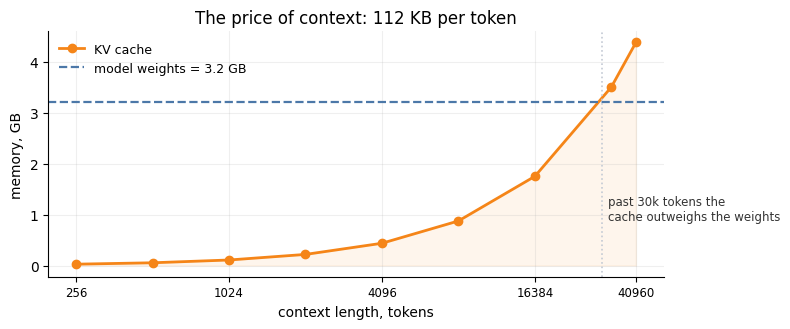

In [9]:
# --- KV cache vs weights: when context starts costing more than the model --------
ctxs = np.array([256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 40960])
kv_gb = kv_per_token * ctxs / 2**30

fig, ax = plt.subplots(figsize=(8.0, 3.4))
ax.plot(ctxs, kv_gb, "o-", color=C_EAGLE, lw=2, ms=6, label="KV cache")
ax.axhline(weights_gb, color=C_NAIVE, lw=1.6, ls="--",
           label=f"model weights = {weights_gb:.1f} GB")
cross = weights_gb * 2**30 / kv_per_token
ax.axvline(cross, color=C_GRID, lw=1.2, ls=":")
ax.text(cross * 1.06, weights_gb * 0.28, f"past {cross/1000:.0f}k tokens the\ncache outweighs the weights",
        fontsize=8.5, color=C_INK)
ax.fill_between(ctxs, 0, kv_gb, color=C_EAGLE, alpha=0.08)
ax.set_xscale("log", base=2)
ticks = [256, 1024, 4096, 16384, 40960]
ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks], fontsize=8.5)
ax.minorticks_off()
ax.set_xlabel("context length, tokens")
ax.set_ylabel("memory, GB")
ax.set_title(f"The price of context: {kv_per_token/1024:.0f} KB per token")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2)
finish("kv_memory")


> **Takeaway.** At short context the KV cache barely registers, but it grows linearly and at Qwen3's 40k-token limit it overtakes the model weights themselves. Against that, the draft tree is free: a hundred nodes take a few megabytes. This is why speculative decoding costs nothing in memory — it spends what is abundant to save what is scarce. The flip side: at long context the arithmetic of [§1](#s1) shifts, because a step now drags the cache along with the weights, so both plain generation and tree verification get dearer together. Every measurement in this walkthrough is taken on short prompts, where the cache does not yet matter.

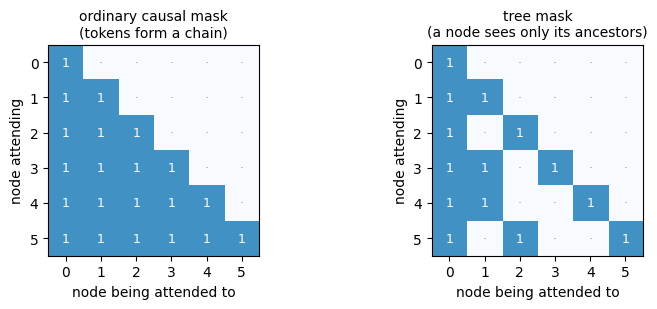

Tree: 1<-0 2<-0 3<-1 4<-1 5<-2
Nodes 3 and 5 sit on different branches, and in the tree mask they cannot see
each other — though a causal mask would let node 5 see node 3 merely for being earlier.


In [10]:
# --- What the tree mask looks like: causal vs tree --------------------------------
# Take a tiny tree and look at its attention mask.
demo_parent = [-1, 0, 0, 1, 1, 2]          # node -> parent, 0 = root
n_demo = len(demo_parent)
mask_tree = np.zeros((n_demo, n_demo))
for i in range(n_demo):
    j = i
    while j != -1:
        mask_tree[i, j] = 1
        j = demo_parent[j]
mask_causal = np.tril(np.ones((n_demo, n_demo)))

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.2))
for ax, m, ttl in ((axes[0], mask_causal, "ordinary causal mask\n(tokens form a chain)"),
                   (axes[1], mask_tree, "tree mask\n(a node sees only its ancestors)")):
    ax.imshow(m, cmap="Blues", vmin=0, vmax=1.6)
    for i in range(n_demo):
        for j in range(n_demo):
            ax.text(j, i, "1" if m[i, j] else "·", ha="center", va="center",
                    fontsize=9, color="white" if m[i, j] else "#99A")
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks(range(n_demo)); ax.set_yticks(range(n_demo))
    ax.set_xlabel("node being attended to"); ax.set_ylabel("node attending")
finish("tree_mask")

print("Tree:", " ".join(f"{i}<-{p}" for i, p in enumerate(demo_parent) if p >= 0))
print("Nodes 3 and 5 sit on different branches, and in the tree mask they cannot see")
print("each other — though a causal mask would let node 5 see node 3 merely for being earlier.")


> **Takeaway.** A causal mask lets every token attend to everything to its left, which is right for a chain. A tree cannot afford that: nodes from different branches share one tensor but represent mutually exclusive continuations. The tree mask restricts each node to its ancestors; without it the branches would bleed into each other and verification would mean nothing.

<a id="s3"></a>
## 3. What EAGLE-3 actually changes — and what shows up in the weights

The cache can hold a whole tree and keep just its accepted path. Now: how the third version of the method differs from the first two, and which of those differences show up not in the paper but in the code.

EAGLE-3 is the third paper of a series: EAGLE-1 (ICML'24), EAGLE-2 (EMNLP'24), EAGLE-3 (NeurIPS'25). Its headline 6.5× is the best single cell of the results table (HumanEval on Vicuna-13B); the per-model averages are more modest, 5.51 on Vicuna-13B and 4.44 on LLaMA-3.1-8B, all under greedy decoding at batch = 1 inside the authors' own framework. The same paper carries a second number that measures something else entirely: in SGLang at batch 64, throughput improves by 1.38×.

**EAGLE-1** ([2401.15077](https://arxiv.org/abs/2401.15077)) noticed that predicting the next token with a small model is hard, while predicting a **feature** — the target model's top-layer hidden state — is noticeably easier: features are more regular than tokens. Its draft model is a single transformer layer that takes the feature `f_t` and the embedding of the already-known token `x_{t+1}`, then continues the feature chain autoregressively. The second input removes sampling uncertainty: the draft knows which token actually came out.

**EAGLE-2** ([2406.16858](https://arxiv.org/abs/2406.16858)) made the draft tree dynamic. The tree shape used to be fixed; now nodes expand by the draft model's confidence, and the `total_token` best candidates by cumulative log-probability make it into the tree. Where the draft is confident the tree grows deep; where it hesitates, it grows wide.

**EAGLE-3** ([2503.01840](https://arxiv.org/abs/2503.01840)) makes three changes:

1. **The draft model stops predicting the feature.** The loss used to carry an `l_fea` term — a regression onto the target's feature. It acted as a regularizer and hit a ceiling: draft quality stopped improving with more training data. EAGLE-3 trains the draft to predict tokens only, and gets the paper's main result: acceptance length starts scaling with data. A subtlety: feature-space autoregression is still there — the draft still feeds its hidden state into its next step. What is gone is the loss that forced that state to match the target's feature.
2. **Three-level fusion.** Instead of one top-layer feature, a concatenation of hidden states from a low, a middle and a top layer, compressed by a 3h → h linear. The top feature is tuned to the very next token and loses information useful several steps ahead.
3. **Training-time test.** At generation time the draft walks a chain of its own outputs, which it never saw in training, and drift accumulates. EAGLE-3 unrolls the draft on its own predictions during training, imitating generation. The closest ancestor of the idea is HASS ([2408.15766](https://arxiv.org/abs/2408.15766)).

Three things on that list are not spelled out in the paper but are immediately visible in the loaded weights: which exact layers the features come from, how far the draft vocabulary is truncated, and which parameter is left dead in the code.

In [11]:
# --- What is inside the draft head -------------------------------------------------
ea = model.ea_layer
draft_vocab = ea.config.draft_vocab_size
full_vocab  = ea.config.vocab_size
head_params = draft_vocab * ea.config.hidden_size

print("1) Target layers feeding the fusion (in the code: idx == 2, L//2, L-3):")
print(f"   low 2 | middle {L//2} | top {L-3}   of {L} layers")
print(f"   fc: {tuple(ea.fc.weight.shape)} — compresses 3h -> h\n")

print("2) The truncated draft vocabulary is not a detail but a condition of viability:")
print(f"   target vocab {full_vocab}, draft vocab {draft_vocab}")
print(f"   draft lm_head: {head_params/1e6:.0f}M params = "
      f"{100*head_params/N_DRAFT:.0f}% of the whole head")
full_head = full_vocab * ea.config.hidden_size
print(f"   with the full vocab the head would weigh {(N_DRAFT - head_params + full_head)/1e6:.0f}M "
      f"= {100*(N_DRAFT - head_params + full_head)/N_TARGET:.0f}% of the target "
      f"(instead of {100*N_DRAFT/N_TARGET:.1f}%)")
print("   on a target this small, EAGLE-3 would not pay off without the truncation\n")

print("3) How the vocabularies connect (d2t stores OFFSETS, not indices):")
print(f"   d2t: {tuple(ea.d2t.shape)} {ea.d2t.dtype}, "
      f"applied as token = i + d2t[i]")
print(f"   t2d: {tuple(ea.t2d.shape)} {ea.t2d.dtype} — coverage mask over the target vocab")
print(f"   target tokens covered: {int(ea.t2d.sum())} of {full_vocab}")
print("   the draft cannot propose a token outside its vocab, but the target is free to")
print("   emit one as the bonus token — correctness is unaffected\n")

print("4) The threshold parameter: lives in the constructor, unused in the EAGLE-3 branch.")
import inspect, re as _re
src_topk = inspect.getsource(type(ea).topK_genrate)
print(f"   self.threshold is set in __init__, mentions inside topK_genrate: "
      f"{len(_re.findall(r'threshold', src_topk))}")
print("   (in cnets1.py — the EAGLE-1/2 draft — it still worked as a pruning threshold)")


1) Target layers feeding the fusion (in the code: idx == 2, L//2, L-3):
   low 2 | middle 14 | top 25   of 28 layers
   fc: (2048, 6144) — compresses 3h -> h

2) The truncated draft vocabulary is not a detail but a condition of viability:
   target vocab 151936, draft vocab 32000
   draft lm_head: 66M params = 48% of the whole head
   with the full vocab the head would weigh 382M = 22% of the target (instead of 8.0%)
   on a target this small, EAGLE-3 would not pay off without the truncation

3) How the vocabularies connect (d2t stores OFFSETS, not indices):
   d2t: (32000,) torch.int64, applied as token = i + d2t[i]
   t2d: (151936,) torch.bool — coverage mask over the target vocab
   target tokens covered: 32000 of 151936
   the draft cannot propose a token outside its vocab, but the target is free to
   emit one as the bonus token — correctness is unaffected

4) The threshold parameter: lives in the constructor, unused in the EAGLE-3 branch.
   self.threshold is set in __init__, men

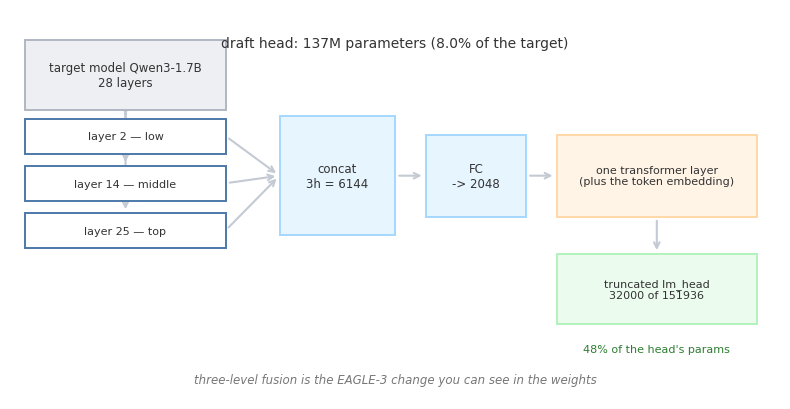

In [12]:
# --- The EAGLE-3 draft head, as a diagram ------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 6.2); ax.axis("off")

def box(x, y, w, h, text, fc, ec, fs=8.5, tc=C_INK):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec,
                               linewidth=1.4, zorder=2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fs, color=tc, zorder=3)

def arrow(x1, y1, x2, y2, color=C_GRID):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5,
                                shrinkA=3, shrinkB=3), zorder=1)

# the target model and its three taps
box(0.2, 4.6, 2.6, 1.1, f"target model Qwen3-1.7B\n{L} layers", "#EDEFF3", "#B0B7C3")
lay = [(2, "low"), (L//2, "middle"), (L-3, "top")]
for k, (idx, name) in enumerate(lay):
    y = 3.9 - k * 0.75
    box(0.2, y, 2.6, 0.55, f"layer {idx} — {name}", "#FFFFFF", C_NAIVE, fs=8)
    arrow(1.5, 4.6, 1.5, y + 0.55)

box(3.5, 2.6, 1.5, 1.9, f"concat\n3h = {3*ea.config.hidden_size}", "#E7F5FF", "#A5D8FF")
for k in range(3):
    arrow(2.8, 3.9 - k*0.75 + 0.28, 3.5, 3.55)
box(5.4, 2.9, 1.3, 1.3, f"FC\n-> {ea.config.hidden_size}", "#E7F5FF", "#A5D8FF")
arrow(5.0, 3.55, 5.4, 3.55)
box(7.1, 2.9, 2.6, 1.3, "one transformer layer\n(plus the token embedding)",
    "#FFF4E6", "#FFD8A8", fs=8)
arrow(6.7, 3.55, 7.1, 3.55)
box(7.1, 1.2, 2.6, 1.1,
    f"truncated lm_head\n{ea.config.draft_vocab_size} of {ea.config.vocab_size}",
    "#EBFBEE", "#B2F2BB", fs=8)
arrow(8.4, 2.9, 8.4, 2.3)
ax.text(8.4, 0.75, f"{100*head_params/N_DRAFT:.0f}% of the head's params", ha="center",
        fontsize=8, color=C_OK)
ax.text(5.0, 5.6, f"draft head: {N_DRAFT/1e6:.0f}M parameters "
        f"({100*N_DRAFT/N_TARGET:.1f}% of the target)", ha="center", fontsize=10, color=C_INK)
ax.text(5.0, 0.25, "three-level fusion is the EAGLE-3 change you can see in the weights",
        ha="center", fontsize=8.5, color="#777", style="italic")
finish("draft_head")


> **Takeaway.** The draft is far simpler than its target: three hidden-state taps, a linear squeeze, one transformer layer and an output vocabulary layer. Nearly half of all its parameters sit in that layer, truncated to 32k tokens instead of the full vocabulary: without the truncation the draft model would weigh a fifth of its target and would never pay for itself at this scale.

<a id="s4"></a>
## 4. Three ways to generate with one model

First, code and weights. The code is the official [SafeAILab/EAGLE](https://github.com/SafeAILab/EAGLE) repository at commit `cb7e0841` — `eagenerate`, `naivegenerate`, the tree construction and the benchmark files all come from there. The draft head is the one that same repository lists in its weights table for Qwen3-1.7B: [AngelSlim/Qwen3-1.7B_eagle3](https://huggingface.co/AngelSlim/Qwen3-1.7B_eagle3), attached here as a Kaggle model. The table marks it as non-authorial — it was trained by the [AngelSlim](https://github.com/Tencent/AngelSlim) team at Tencent: the EAGLE authors' own ready-made heads cover only Vicuna and LLaMA. This matters more than it sounds when reading the numbers: the head was trained on English dialogue, and off that domain it behaves very differently ([§5](#s5)).

All three ways run the same weights: one model, three loops calling it.

**`generate` from `transformers`** — what an ordinary user gets. An honest external reference, but it uses a different attention backend and a different cache, so it does not isolate the effect of speculation.

**`naivegenerate`** — the plain autoregressive loop from the EAGLE repository: the same modified model and the same static KV buffer as the speculative loop. This is the baseline the paper computes its speedups against, and the one that isolates the method's contribution: between it and `eagenerate` there is exactly one difference — speculation.

**`eagenerate`** — EAGLE-3 itself.

Every number below is reported against both baselines. The uncomfortable part: on this card `naivegenerate` runs about 10% slower than stock `generate` — it has no flash attention — so a speedup measured against it flatters the method slightly. Hence two columns in the final table.

One more methodological choice. All three stop at EOS, and their texts diverge ([§10](#s10) covers why), so tokens-per-second would be computed over different work. To keep the comparison honest, the measurements suppress the end-of-sequence token and force every loop to emit the same number of tokens.

Below is the shared measurement harness: one way to build a prompt, a stopwatch around generation, and a tree-shape switch. The EOS suppression from the previous paragraph lives here too.

In [13]:
# --- Measurement utilities: equal work for all three loops -----------------------
from transformers import AutoModelForCausalLM

def encode(question, thinking=False):
    text = tok.apply_chat_template(
        [{"role": "user", "content": question}],
        tokenize=False, add_generation_prompt=True, enable_thinking=thinking)
    return torch.as_tensor(tok([text]).input_ids).cuda()

class NoEOS:
    """Suppresses the EOS stop: every loop emits exactly N tokens.

    Without this, EAGLE and plain generation stop at different points and divide
    different token counts by different times — comparing different work.
    """
    def __enter__(self):
        self._saved = model.tokenizer.eos_token_id
        model.tokenizer.eos_token_id = -1          # an id that never occurs in output
        return self
    def __exit__(self, *a):
        model.tokenizer.eos_token_id = self._saved

def run_naive(ids, n_tokens):
    with NoEOS():
        (out, new, _), dt = timed(model.naivegenerate, ids, temperature=0.0,
                                  max_new_tokens=n_tokens, log=True)
    return dict(tokens=int(new), sec=dt, steps=int(new), ids=out)

def run_eagle(ids, n_tokens):
    with NoEOS():
        (out, new, idx), dt = timed(model.eagenerate, ids, temperature=0.0,
                                    max_new_tokens=n_tokens, log=True)
    return dict(tokens=int(new), sec=dt, steps=idx + 1, ids=out)

def ms_per_token(r):
    return 1000 * r["sec"] / r["tokens"]

def set_tree(total_token, depth, top_k):
    """Tree shape lives in plain draft-model attributes — no model reload needed."""
    model.ea_layer.top_k = top_k
    model.ea_layer.depth = depth
    model.ea_layer.total_tokens = total_token - 1
    model.ea_layer.init_tree()

WARM = encode("Explain in two sentences why the sky is blue.")
with torch.no_grad():
    run_eagle(WARM, 32); run_naive(WARM, 32)


<a id="s5"></a>
## 5. Benchmarks from the paper

The three loops are ready; what they need is an honest task set. Hand-written prompts are the weak spot of any speed claim — they can always be tuned toward a convenient answer. Fortunately, the EAGLE repository ships the very sets the paper reports on: MT-Bench (dialogue), GSM8K (arithmetic word problems), HumanEval (code), Alpaca (instructions) — 80 questions each. I take the first five of each: a full 320-question sweep does not fit into a free session.

The fifth set is five Russian prompts of my own — not a public benchmark. The draft head was community-trained on English data, and I want to see the method operate outside its domain. As it turns out, that regime produces the most instructive result of the whole walkthrough.

Call order within a question is fixed — stock `generate`, then `naivegenerate`, then `eagenerate`; no randomization. All three run back-to-back on the same question, so GPU thermal drift hits them almost equally: the run-to-run spread of plain generation is a fraction of a percent ([§7](#s7) prints it explicitly).

The numbers in this section are taken at the starting tree shape `60/7/10` (total_token / depth / top_k) set at model load. [§7](#s7) will show this shape is not optimal: a shallower tree comes out roughly 10% faster ([§7](#s7) prints the sweep and the winning shape; the exact figure moves a few points between runs). I did not rerun the full benchmark at the chosen shape: a Kaggle session is finite, and the section's conclusion — a two-and-a-half-fold gap between domains — is a ratio of two speedups measured at the same shape, so a shift common to both cancels out of it.

Assembling the five sets: four from the paper's repository plus my Russian one.

In [14]:
# --- Question sets ----------------------------------------------------------------
BENCH_DIR = "/kaggle/working/EAGLE/eagle/data"
N_Q   = 3 if QUICK else 5          # questions taken from each set
N_TOK = 128 if QUICK else 192      # exactly this many new tokens per run

def load_bench(name):
    with open(f"{BENCH_DIR}/{name}/question.jsonl") as f:
        return [json.loads(l)["turns"][0] for l in f]

BENCH = {
    "MT-Bench":  load_bench("mt_bench")[:N_Q],
    "GSM8K":     load_bench("gsm8k")[:N_Q],
    "HumanEval": load_bench("humaneval")[:N_Q],
    "Alpaca":    load_bench("alpaca")[:N_Q],
    "Russian":  [
        "Объясни в трёх предложениях, почему небо голубое.",
        "Напиши функцию на Python, которая проверяет, является ли строка палиндромом.",
        "Составь короткое деловое письмо с просьбой перенести встречу.",
        "Реши задачу по шагам: в корзине 48 яблок, треть раздали. Сколько осталось?",
        "Перечисли пять городов Золотого кольца и чем известен каждый.",
    ][:N_Q],
}
assert LANG_SET in BENCH, f"LANG_SET={LANG_SET!r} must be a key of BENCH — add your set above"
for k, v in BENCH.items():
    print(f"{k:10s}: {len(v)} questions | first: {v[0][:64]!r}")


MT-Bench  : 5 questions | first: 'Compose an engaging travel blog post about a recent trip to Hawa'
GSM8K     : 5 questions | first: "Darrell and Allen's ages are in the ratio of 7:11. If their tota"
HumanEval : 5 questions | first: 'Complete the code I provided.\n\ndef below_threshold(l: list, t: i'
Alpaca    : 5 questions | first: 'What would be the best type of exercise for a person who has art'
Russian   : 5 questions | first: 'Объясни в трёх предложениях, почему небо голубое.'


This is where [§5](#s5)'s numbers come from: every loop emits a fixed number of tokens, and time is divided by that.

In [15]:
# --- Main benchmark: three loops back-to-back per question, equal work -----------
hf = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float16, device_map={"": 0}).eval()
with torch.no_grad():
    hf.generate(WARM, max_new_tokens=32, do_sample=False, min_new_tokens=32,
                temperature=None, top_p=None, top_k=None)

rows = []
for bench_name, questions in BENCH.items():
    for qi, q in enumerate(questions):
        ids = encode(q)
        # three loops back-to-back on one question -> thermal drift hits all equally
        with torch.no_grad():
            out, dt = timed(hf.generate, ids, max_new_tokens=N_TOK, min_new_tokens=N_TOK,
                            do_sample=False, temperature=None, top_p=None, top_k=None)
        n_hf = out.shape[1] - ids.shape[1]
        r_nv = run_naive(ids, N_TOK)
        r_ea = run_eagle(ids, N_TOK)
        rows.append(dict(
            bench=bench_name, q=qi,
            hf_ms=1000 * dt / n_hf,
            naive_ms=ms_per_token(r_nv),
            eagle_ms=ms_per_token(r_ea),
            tau=r_ea["tokens"] / r_ea["steps"],
        ))
        print(f"{bench_name:10s} q{qi}: naive {rows[-1]['naive_ms']:5.1f} ms/tok | "
              f"eagle {rows[-1]['eagle_ms']:5.1f} ms/tok | τ {rows[-1]['tau']:4.2f}")

del hf
gc.collect(); torch.cuda.empty_cache()

bench_df = pd.DataFrame(rows)
bench_df["speedup_naive"] = bench_df.naive_ms / bench_df.eagle_ms
bench_df["speedup_hf"]    = bench_df.hf_ms / bench_df.eagle_ms


MT-Bench   q0: naive  46.9 ms/tok | eagle  27.4 ms/tok | τ 2.55
MT-Bench   q1: naive  47.0 ms/tok | eagle  18.2 ms/tok | τ 3.78
MT-Bench   q2: naive  46.3 ms/tok | eagle  23.3 ms/tok | τ 2.92
MT-Bench   q3: naive  49.3 ms/tok | eagle  27.1 ms/tok | τ 2.74
MT-Bench   q4: naive  48.0 ms/tok | eagle  27.8 ms/tok | τ 2.54
GSM8K      q0: naive  47.5 ms/tok | eagle  18.7 ms/tok | τ 3.75
GSM8K      q1: naive  47.6 ms/tok | eagle  21.6 ms/tok | τ 3.25
GSM8K      q2: naive  46.8 ms/tok | eagle  15.8 ms/tok | τ 4.43
GSM8K      q3: naive  46.6 ms/tok | eagle  21.4 ms/tok | τ 3.27
GSM8K      q4: naive  47.1 ms/tok | eagle  19.1 ms/tok | τ 3.68
HumanEval  q0: naive  46.7 ms/tok | eagle  16.3 ms/tok | τ 4.29
HumanEval  q1: naive  47.7 ms/tok | eagle  20.4 ms/tok | τ 3.50
HumanEval  q2: naive  47.1 ms/tok | eagle  21.4 ms/tok | τ 3.33
HumanEval  q3: naive  47.0 ms/tok | eagle  17.6 ms/tok | τ 4.02
HumanEval  q4: naive  47.5 ms/tok | eagle  17.9 ms/tok | τ 3.98
Alpaca     q0: naive  47.0 ms/tok | eagl

Aggregating by set. The per-question spread goes right next to the mean: without it there is no telling whether two sets differ or it is just noise.

In [16]:
# --- Per-set summary with spread --------------------------------------------------
summary = bench_df.groupby("bench").agg(
    tau=("tau", "mean"),
    tau_min=("tau", "min"), tau_max=("tau", "max"),
    speedup=("speedup_naive", "mean"),
    sp_min=("speedup_naive", "min"), sp_max=("speedup_naive", "max"),
    speedup_hf=("speedup_hf", "mean"),
).reindex(list(BENCH.keys())).round(2)
def show_table(df):
    """Kaggle renders styled tables smaller than body text — set the size explicitly."""
    return df.style.set_table_styles(
        [{"selector": "th", "props": [("font-size", "13px")]}]
    ).set_properties(**{"font-size": "13px"})

display(show_table(summary))

overall_tau = bench_df.tau.mean()
overall_sp  = bench_df.speedup_naive.mean()
print(f"All sets combined: τ = {overall_tau:.2f}, "
      f"speedup {overall_sp:.2f}x vs naivegenerate, "
      f"{bench_df.speedup_hf.mean():.2f}x vs stock generate")
in_dom  = bench_df[bench_df.bench != LANG_SET]
out_dom = bench_df[bench_df.bench == LANG_SET]
print(f"  in-domain sets:    τ = {in_dom.tau.mean():.2f}, speedup {in_dom.speedup_naive.mean():.2f}x")
print(f"  {LANG_SET + ' set:':18s} τ = {out_dom.tau.mean():.2f}, speedup {out_dom.speedup_naive.mean():.2f}x")


,tau,tau_min,tau_max,speedup,sp_min,sp_max,speedup_hf
bench,,,,,,,
MT-Bench,2.910000,2.540000,3.780000,1.970000,1.710000,2.590000,1.740000
GSM8K,3.680000,3.250000,4.430000,2.470000,2.180000,2.970000,2.230000
HumanEval,3.820000,3.330000,4.290000,2.550000,2.200000,2.870000,2.270000
Alpaca,3.190000,2.710000,3.710000,2.150000,1.830000,2.490000,1.930000
Russian,1.380000,1.120000,1.740000,0.940000,0.760000,1.160000,0.840000


All sets combined: τ = 3.00, speedup 2.02x vs naivegenerate, 1.80x vs stock generate
  in-domain sets:    τ = 3.40, speedup 2.28x
  Russian set:       τ = 1.38, speedup 0.94x


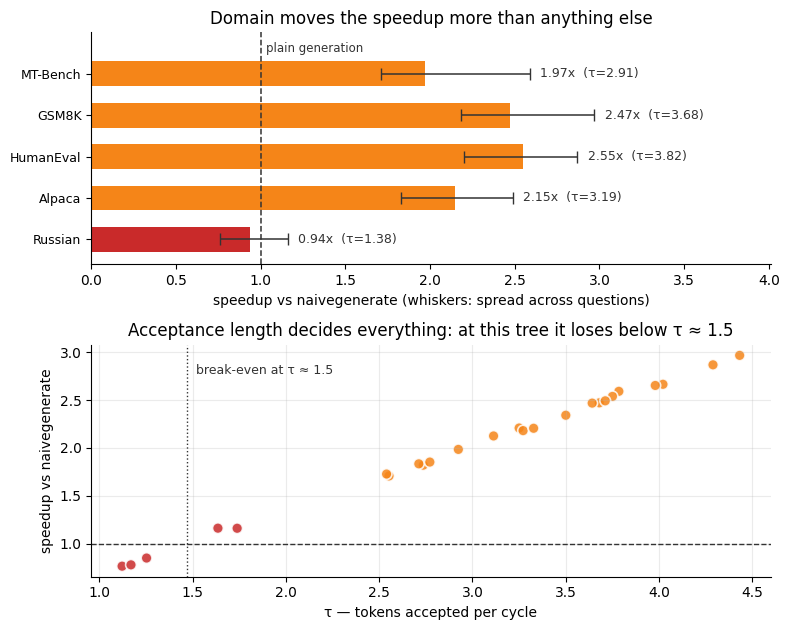

In [17]:
# --- Figure: speedup by set, with per-question spread ----------------------------
order = list(BENCH.keys())
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.0, 6.4))

y = np.arange(len(order))
means = [summary.loc[b, "speedup"] for b in order]
lo = [summary.loc[b, "speedup"] - summary.loc[b, "sp_min"] for b in order]
hi = [summary.loc[b, "sp_max"] - summary.loc[b, "speedup"] for b in order]
colors = [C_EAGLE if b != LANG_SET else "#C92A2A" for b in order]
ax1.barh(y, means, xerr=[lo, hi], height=0.6, color=colors, edgecolor="none",
         error_kw=dict(ecolor=C_INK, lw=1.1, capsize=4))
ax1.axvline(1.0, color=C_INK, lw=1.1, ls="--")
for i, b in enumerate(order):
    ax1.text(summary.loc[b, "sp_max"] + 0.06, i,
             f'{means[i]:.2f}x  (τ={summary.loc[b, "tau"]:.2f})',
             va="center", fontsize=9, color=C_INK)
ax1.set_yticks(y); ax1.set_yticklabels(order, fontsize=9)
ax1.set_xlabel("speedup vs naivegenerate (whiskers: spread across questions)")
ax1.set_xlim(0, max(summary.sp_max) * 1.35)
ax1.set_ylim(len(order) - 0.4, -1.0)
ax1.text(1.03, -0.62, "plain generation", fontsize=8.5, color=C_INK, va="center")
ax1.set_title("Domain moves the speedup more than anything else")
ax1.spines[["top", "right"]].set_visible(False)

ax2.scatter(bench_df.tau, bench_df.speedup_naive,
            c=[C_EAGLE if b != LANG_SET else "#C92A2A" for b in bench_df.bench],
            s=60, alpha=0.85, edgecolor="white", linewidth=1.2)
ax2.axhline(1.0, color=C_INK, lw=1.0, ls="--")
# where the line crosses 1.0: a linear fit through the measurements
_fit = np.polyfit(bench_df.tau, bench_df.speedup_naive, 1)
tau_break = (1.0 - _fit[1]) / _fit[0]
ax2.axvline(tau_break, color=C_INK, lw=1.0, ls=":")
ax2.text(tau_break + 0.05, bench_df.speedup_naive.max() * 0.97,
         f"break-even at τ ≈ {tau_break:.1f}", fontsize=9, color=C_INK, va="top")
ax2.set_xlabel("τ — tokens accepted per cycle")
ax2.set_ylabel("speedup vs naivegenerate")
ax2.set_title(f"Acceptance length decides everything: at this tree it loses below τ ≈ {tau_break:.1f}")
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(alpha=0.25)
finish("bench_by_domain")


> **Takeaway.** Domain decides everything. On the English sets acceptance length holds near 3.4 and the method better than doubles the speed; on the Russian prompts it drops to about 1.4 and the same machinery starts losing to plain generation. The spread across questions inside a set is visibly smaller than the gap between sets — so it is the domain, not a few unlucky prompts. The lower panel shows the mechanics: speedup is almost linear in acceptance length, and below the break-even point marked on the plot the line dips under 1.

<div style="background-color:#fff4e6;border:2px solid #ffd8a8;border-radius:6px;padding:14px 16px;color:#111;font-size:15px">
<strong>What this means in practice.</strong> On the English sets the method delivers a steady
speedup; on the Russian ones it <em>slows generation down</em>. That set is out of the head's
training distribution and in another language at once, and this run cannot separate the two: the
head was community-trained on English dialogue, so training data is the likely cause, but confirming
it needs an out-of-domain English set or a Russian-trained head, and neither is here. Whatever the
reason, off that domain it rarely guesses right, τ sinks toward 1, and the build-tree → verify → discard cycle degenerates
into pure overhead on top of an ordinary step.
<br><br>
Only it is measured at the <em>starting</em> tree, and that tree is deep. At the shape <a href="#s7">§7</a> goes on to pick there is no slowdown — <a href="#scaling">§11</a> runs a subset
of the same Russian prompts and comes out slightly ahead, at practically the same acceptance length.
So the number above is not a property of the domain alone: it is measured at a deep tree, and at a
shallow one the same set behaves differently. Domain sets how much the method can win; depth sets how
much it can lose. That is not a guess: <a href="#s7">§7</a> runs the same depth sweep on the Russian set, and the curve crosses 1.0 while acceptance length barely moves.
<br><br>
Speculative decoding guarantees the output, not the gain: measure acceptance length on your own
prompt distribution instead of quoting the paper's.
</div>

<a id="s6"></a>
## 6. The draft tree: anatomy of a single step

Time to look at one tree whole.

Tree shape is set by three parameters:

- `top_k` sets the width: how many continuations open at each node;
- `depth` sets how many expansion steps follow the first draft pass: a cycle costs `depth` + 1 draft launches, and the tree carries `depth` + 1 levels;
- `total_token` sets the budget: how many of all opened nodes stay in the tree.

Construction goes like this. The draft model runs once, then takes `depth` more steps; at each step every one of the top-k current nodes opens its own top-k continuations, forming a candidate pool. Each candidate carries a cumulative log-probability — the sum along its whole path from the root. The `total_token` best by that sum are selected from the pool, and the tree mask and position indices are built over them. The dynamic selection is EAGLE-2's contribution: in EAGLE-1 the tree shape was fixed in advance, blind to context.

The target model verifies the whole tree in one pass with the tree mask from [§2](#s2). All root-to-leaf paths are read out of its logits; under greedy decoding a path is accepted exactly up to the position where a draft token stops matching the target's `argmax`. A **bonus token** is appended to the accepted path — the one the target itself predicted at the last accepted position. So even at zero acceptance the cycle emits one token, like plain generation: in target-model passes, the method cannot do worse.

Below is an instrumented copy of the loop: same logic, plus a record of the tree and the verification result at every step.


In [18]:
# --- Instrumented loop: recording every tree --------------------------------------
from eagle.model.utils import (initialize_tree, tree_decoding, evaluate_posterior,
                               update_inference_inputs, reset_tree_mode)
from eagle.model.kv_cache import initialize_past_key_values

@torch.no_grad()
def eagenerate_traced(ids, max_new_tokens=96, max_length=2048):
    """A mirror of EaModel.eagenerate (greedy mode) that records a per-step trace."""
    padding = (torch.zeros(1, 1, dtype=torch.long) - 1).to(ids.device)
    input_ids = ids.clone()
    model.ea_layer.reset_kv()

    if hasattr(model, "past_key_values"):
        past_key_values = model.past_key_values
        past_key_values_data = model.past_key_values_data
        current_length_data = model.current_length_data
        current_length_data.zero_()
    else:
        (past_key_values, past_key_values_data,
         current_length_data) = initialize_past_key_values(model.base_model, max_length=max_length)
        model.past_key_values = past_key_values
        model.past_key_values_data = past_key_values_data
        model.current_length_data = current_length_data

    reset_tree_mode(model)
    draft_tokens, retrieve_indices, tree_mask, tree_position_ids, logits, hidden_state, sample_token = \
        initialize_tree(input_ids, model, past_key_values, None)

    trace, new_token = [], 0
    for _ in range(max_length - model.ea_layer.total_tokens - 10):
        model.base_model.model.tree_mask = tree_mask
        draft_tokens = draft_tokens.to(input_ids.device)
        step = {
            "nodes": draft_tokens[0].tolist(),
            "ancestors": tree_mask[0, 0].bool().cpu().numpy(),
            "depths": tree_position_ids.cpu().tolist(),
            "paths": retrieve_indices.cpu().tolist(),
        }
        logits, hidden_state_new, outputs = tree_decoding(
            model, draft_tokens, past_key_values, tree_position_ids, input_ids, retrieve_indices)
        draft_tokens_p = torch.cat((draft_tokens, padding), dim=1)
        candidates = draft_tokens_p[0, retrieve_indices]
        best_candidate, accept_length, sample_p = evaluate_posterior(logits, candidates, None)

        step["best_path"] = int(best_candidate)
        step["accept_length"] = int(accept_length)
        step["accepted_nodes"] = retrieve_indices[best_candidate][:accept_length + 1].tolist()
        step["bonus_token"] = int(torch.argmax(sample_p))
        trace.append(step)

        input_ids, draft_tokens, retrieve_indices, tree_mask, tree_position_ids, new_token, hidden_state, sample_token = \
            update_inference_inputs(input_ids, candidates, best_candidate, accept_length,
                                    retrieve_indices, None, new_token, past_key_values_data,
                                    current_length_data, model, hidden_state_new, sample_p)
        if new_token > max_new_tokens:
            break
    return input_ids, trace

set_tree(16, 5, 3)      # a smaller tree for the figure, or the labels collide
TRACE_Q = BENCH["MT-Bench"][0]
_, trace = eagenerate_traced(encode(TRACE_Q), max_new_tokens=96)
acc = [s["accept_length"] + 1 for s in trace]
print(f"{len(trace)} steps, {sum(acc)} tokens emitted, τ = {np.mean(acc):.2f}")
print("accepted per cycle:", acc)


43 steps, 98 tokens emitted, τ = 2.28
accepted per cycle: [2, 1, 3, 3, 2, 2, 1, 3, 1, 4, 2, 1, 3, 2, 1, 2, 1, 3, 1, 2, 2, 4, 3, 2, 2, 2, 5, 2, 2, 1, 3, 1, 5, 2, 1, 1, 3, 3, 5, 1, 4, 2, 2]


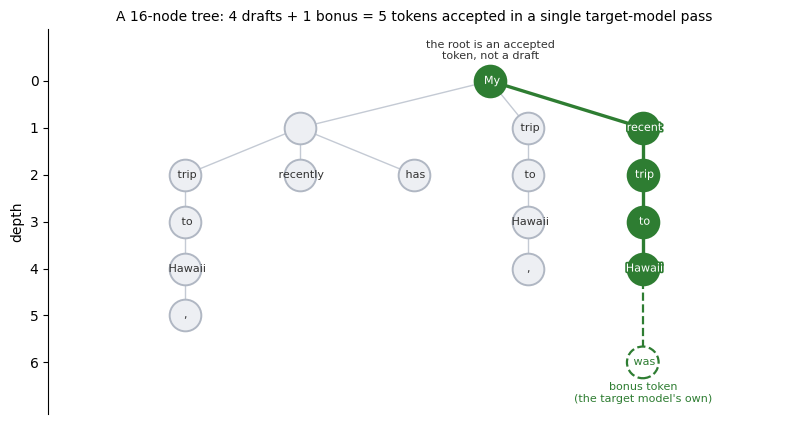

Paths of this tree (first 6):
  [rejected]  My ->   ->  recently
  [rejected]  My ->   ->  has
  [ACCEPTED]  My ->  recent ->  trip ->  to ->  Hawaii
  [rejected]  My ->  trip ->  to ->  Hawaii -> ,
  [rejected]  My ->   ->  trip ->  to ->  Hawaii -> ,


In [19]:
# --- Drawing a real tree from the run ---------------------------------------------
def tree_layout(step):
    n = len(step["nodes"]); anc = step["ancestors"]; depths = step["depths"]
    parent = [-1] * n
    for i in range(1, n):
        cand = [j for j in range(n) if anc[i][j] and j != i and depths[j] == depths[i] - 1]
        parent[i] = cand[0] if cand else 0
    children = {i: [] for i in range(n)}
    for i in range(1, n):
        children[parent[i]].append(i)
    xs = {}; nxt = [0]
    def place(v):
        if not children[v]:
            xs[v] = nxt[0]; nxt[0] += 1
        else:
            for k in children[v]:
                place(k)
            xs[v] = sum(xs[k] for k in children[v]) / len(children[v])
    place(0)
    return parent, xs

def show_token(t):
    return repr(tok.decode([t]))[1:-1][:9]

def plot_tree(step, title):
    parent, xs = tree_layout(step)
    n = len(step["nodes"]); depths = step["depths"]
    accepted = set(step["accepted_nodes"])
    n_leaves = int(max(xs.values())) + 1
    node_fs = 8.0 if n_leaves <= 8 else (7.0 if n_leaves <= 12 else 6.0)
    node_sz = 520 if n_leaves <= 8 else (400 if n_leaves <= 12 else 300)
    fig, ax = plt.subplots(figsize=(8.0, max(4.0, 0.62 * (max(depths) + 2))))
    for i in range(1, n):
        p = parent[i]
        on = i in accepted and p in accepted
        ax.plot([xs[p], xs[i]], [-depths[p], -depths[i]],
                color=C_OK if on else C_GRID, lw=2.4 if on else 1.0, zorder=1)
    for i in range(n):
        on = i in accepted
        ax.scatter([xs[i]], [-depths[i]], s=node_sz, color=C_OK if on else "#EDEFF3",
                   edgecolor=C_OK if on else "#B0B7C3", linewidth=1.4, zorder=2)
        # white-on-green loses any letter that overflows the circle onto the page;
        # a stroke in the node's own colour keeps the whole token readable
        ax.annotate(show_token(step["nodes"][i]), (xs[i], -depths[i]), ha="center",
                    va="center", fontsize=node_fs, color="white" if on else C_INK, zorder=3,
                    path_effects=[pe.withStroke(linewidth=2.4, foreground=C_OK)] if on else None)
    last = step["accepted_nodes"][-1]
    # the bonus goes one level below the deepest node — guaranteed empty space there
    bx, by = xs[last], -(max(depths) + 1)
    ax.plot([xs[last], bx], [-depths[last], by], color=C_OK, lw=1.6, ls="--", zorder=1)
    ax.scatter([bx], [by], s=node_sz, color="white", edgecolor=C_OK, linewidth=1.6,
               linestyle="--", zorder=2)
    ax.annotate(show_token(step["bonus_token"]), (bx, by), ha="center", va="center",
                fontsize=node_fs, color=C_OK, zorder=3)
    ax.annotate("bonus token\n(the target model's own)", (bx, by - 0.42), fontsize=8,
                color=C_OK, ha="center", va="top")
    ax.annotate("the root is an accepted\ntoken, not a draft", (xs[0], 0.42), fontsize=8,
                color=C_INK, ha="center", va="bottom")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("depth"); ax.set_xticks([])
    yt = list(range(-max(depths) - 1, 1))
    ax.set_yticks(yt); ax.set_yticklabels([str(-y) for y in yt])
    ax.set_ylim(min(yt) - 1.1, 1.1)
    xall = list(xs.values()) + [bx]
    ax.set_xlim(min(xall) - 1.2, max(xall) + 1.2)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    finish("draft_tree")

best = int(np.argmax([s["accept_length"] for s in trace]))
st = trace[best]
plot_tree(st, f"A {len(st['nodes'])}-node tree: {st['accept_length']} drafts "
              f"+ 1 bonus = {st['accept_length']+1} tokens accepted "
              f"in a single target-model pass")

print("Paths of this tree (first 6):")
for r, path in enumerate(st["paths"][:6]):
    toks = [show_token(st["nodes"][i]) for i in path if i >= 0]
    print(f"  [{'ACCEPTED' if r == st['best_path'] else 'rejected':8s}] " + " -> ".join(toks))


> **Takeaway.** Here is what separates a tree from a chain: the draft proposed several mutually exclusive continuations, and the target verified them all in one pass. The green path matched its own choice and was accepted whole; the other branches were dropped. The last token of the path comes from the target itself, which is why even a complete miss leaves the cycle no worse than an ordinary step.

### What branching itself buys

Two things, looked at separately.

First, acceptance by depth: the share of cycles that survived to depth 1, 2, 3 and so on. It shows exactly where the draft model runs out of steam.

Second, how much the branching adds. The degenerate tree at `top_k = 1` is classic chain speculative decoding: the draft proposes one sequence and the target checks it. Chain and tree are compared at the same depth, on the same prompt, with the same number of target-model passes.


tree τ   (16/5/3): 2.28 tokens per cycle
chain τ   (6/5/1): 1.64 — same draft model, same depth, no branching
=> branching adds 39% to acceptance length at the same number of target-model passes


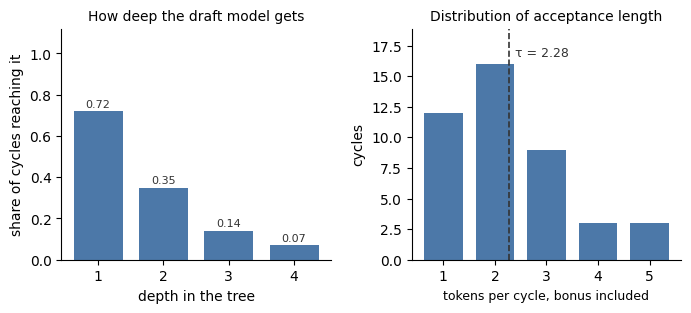

In [20]:
# --- Acceptance by depth, and the contribution of branching -----------------------
max_d = max(s["accept_length"] for s in trace)
alpha = [np.mean([s["accept_length"] >= d for s in trace]) for d in range(1, max_d + 1)]

# Chain vs tree at equal depth: top_k=1 is speculative decoding without
# branching — a degenerate case of the very same code.
tau_tree = np.mean([s["accept_length"] + 1 for s in trace])
set_tree(total_token=6, depth=5, top_k=1)          # a chain of the same depth
_, chain_trace = eagenerate_traced(encode(TRACE_Q), max_new_tokens=96)
tau_chain = np.mean([s["accept_length"] + 1 for s in chain_trace])
set_tree(16, 5, 3)                                  # restore the tree for the figure

print(f"tree τ   (16/5/3): {tau_tree:.2f} tokens per cycle")
print(f"chain τ   (6/5/1): {tau_chain:.2f} — same draft model, same depth, no branching")
print(f"=> branching adds {100*(tau_tree/tau_chain - 1):.0f}% to acceptance length "
      f"at the same number of target-model passes")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.0, 3.0),
                             gridspec_kw={"wspace": 0.30})
a1.bar(range(1, len(alpha) + 1), alpha, color=C_NAIVE, edgecolor="none", width=0.75)
for i, v in enumerate(alpha):
    a1.text(i + 1, v + 0.02, f"{v:.2f}", ha="center", fontsize=8, color=C_INK)
a1.set_xlabel("depth in the tree"); a1.set_ylabel("share of cycles reaching it")
a1.set_title("How deep the draft model gets", fontsize=10)
a1.set_ylim(0, 1.12); a1.spines[["top", "right"]].set_visible(False)

vals, cnts = np.unique([s["accept_length"] + 1 for s in trace], return_counts=True)
a2.bar(vals, cnts, color=C_NAIVE, edgecolor="none", width=0.75)
a2.axvline(tau_tree, color=C_INK, lw=1.2, ls="--")
a2.text(tau_tree + 0.12, max(cnts) * 1.04, f"τ = {tau_tree:.2f}", fontsize=9, color=C_INK)
a2.set_ylim(0, max(cnts) * 1.18)
a2.set_xlabel("tokens per cycle, bonus included", fontsize=9); a2.set_ylabel("cycles")
a2.set_title("Distribution of acceptance length", fontsize=10)
a2.set_xticks(vals); a2.spines[["top", "right"]].set_visible(False)
finish("acceptance")


> **Takeaway.** Acceptance falls off fast: only 72% of cycles get even one draft token accepted, 35% reach two, and 7% reach four — the deepest any cycle got here. The next section confirms this with a proper sweep, but the conclusion is visible already: growing the tree beyond a few levels is pointless, because depth is paid for every time and pays back rarely.

<a id="s7"></a>
## 7. Tree shape: two one-knob sweeps

[§1](#s1) predicts an asymmetry. **Width** means extra nodes inside the same verification pass, which stays flat to about 192 tokens — so width is almost free. **Depth** means additional sequential launches of the draft model, each with a fixed price nothing can hide.

To test this, one knob moves at a time: first `total_token` is fixed and depth sweeps, then depth is fixed and `total_token` sweeps. Every point is measured three times, and the plot shows mean and spread — without that, picking a configuration on a couple-percent difference is meaningless, since run-to-run GPU noise is the same order.

The cell below runs both sweeps, printing mean, spread and acceptance length for every point.

In [21]:
# --- Two-factor ablation with repeats ---------------------------------------------
ABL_Q = [BENCH["GSM8K"][0], BENCH["MT-Bench"][0]]
ABL_TOK = 128 if QUICK else 192
REPS = 2 if QUICK else 3

def measure_tree(total_token, depth, top_k, reps=REPS, qs=None):
    qs = qs or ABL_Q
    set_tree(total_token, depth, top_k)
    with torch.no_grad():
        run_eagle(WARM, 32)
    per_rep = []
    for _ in range(reps):
        ms, taus = [], []
        for q in qs:
            r = run_eagle(encode(q), ABL_TOK)
            ms.append(ms_per_token(r)); taus.append(r["tokens"] / r["steps"])
        per_rep.append((float(np.mean(ms)), float(np.mean(taus))))
    ms_arr = np.array([p[0] for p in per_rep])
    return dict(ms=ms_arr.mean(), ms_std=ms_arr.std(),
                tau=float(np.mean([p[1] for p in per_rep])))

# the plain-generation baseline — same repeats, same token count
nv = []
for _ in range(REPS):
    nv.append(np.mean([ms_per_token(run_naive(encode(q), ABL_TOK)) for q in ABL_Q]))
NAIVE_MS, NAIVE_STD = float(np.mean(nv)), float(np.std(nv))
print(f"plain generation: {NAIVE_MS:.2f} ± {NAIVE_STD:.2f} ms/token "
      f"(spread {100*NAIVE_STD/NAIVE_MS:.1f}%)\n")

DEPTHS = [2, 4, 6, 8] if QUICK else [1, 2, 3, 4, 6, 8, 10]
SIZES_T = [16, 48, 96] if QUICK else [8, 16, 32, 48, 64, 96, 128]

print("A. depth sweep at fixed total_token = 64, top_k = 10")
depth_res = {}
for d in DEPTHS:
    depth_res[d] = measure_tree(64, d, 10)
    print(f"   depth={d:2d}: {depth_res[d]['ms']:5.2f} ± {depth_res[d]['ms_std']:.2f} ms/tok | "
          f"τ {depth_res[d]['tau']:4.2f} | speedup {NAIVE_MS/depth_res[d]['ms']:4.2f}x")

# §5's slowdown was measured at a deep tree. The same depth sweep on the out-of-domain
# set shows where the curve actually crosses 1.0 — otherwise that stays a guess.
RU_Q = BENCH[LANG_SET][:2]
RU_DEPTHS = [2, 7] if QUICK else [2, 4, 7, 10]
nv_ru = []
for _ in range(REPS):
    nv_ru.append(np.mean([ms_per_token(run_naive(encode(q), ABL_TOK)) for q in RU_Q]))
NAIVE_RU = float(np.mean(nv_ru))
print(f"\nC. depth on the out-of-domain set (plain generation {NAIVE_RU:.2f} ms/tok)")
depth_ru = {}
for d in RU_DEPTHS:
    depth_ru[d] = measure_tree(64, d, 10, qs=RU_Q)
    print(f"   depth={d:2d}: {depth_ru[d]['ms']:5.2f} ± {depth_ru[d]['ms_std']:.2f} ms/tok | "
          f"τ {depth_ru[d]['tau']:4.2f} | speedup {NAIVE_RU/depth_ru[d]['ms']:4.2f}x")

print("\nB. tree-size sweep at fixed depth = 6, top_k = 10")
size_res = {}
for s in SIZES_T:
    size_res[s] = measure_tree(s, 6, 10)
    print(f"   total_token={s:3d}: {size_res[s]['ms']:5.2f} ± {size_res[s]['ms_std']:.2f} ms/tok | "
          f"τ {size_res[s]['tau']:4.2f} | speedup {NAIVE_MS/size_res[s]['ms']:4.2f}x")


plain generation: 46.85 ± 0.45 ms/token (spread 1.0%)

A. depth sweep at fixed total_token = 64, top_k = 10
   depth= 1: 21.32 ± 0.12 ms/tok | τ 2.51 | speedup 2.20x
   depth= 2: 20.48 ± 0.07 ms/tok | τ 2.78 | speedup 2.29x
   depth= 3: 20.55 ± 0.08 ms/tok | τ 2.91 | speedup 2.28x
   depth= 4: 21.07 ± 0.13 ms/tok | τ 3.04 | speedup 2.22x
   depth= 6: 22.66 ± 0.35 ms/tok | τ 3.09 | speedup 2.07x
   depth= 8: 23.92 ± 0.06 ms/tok | τ 3.12 | speedup 1.96x
   depth=10: 25.84 ± 0.25 ms/tok | τ 3.12 | speedup 1.81x

C. depth on the out-of-domain set (plain generation 46.77 ms/tok)
   depth= 2: 40.36 ± 0.19 ms/tok | τ 1.47 | speedup 1.16x
   depth= 4: 44.92 ± 0.29 ms/tok | τ 1.42 | speedup 1.04x
   depth= 7: 48.97 ± 0.18 ms/tok | τ 1.50 | speedup 0.96x
   depth=10: 56.44 ± 0.59 ms/tok | τ 1.42 | speedup 0.83x

B. tree-size sweep at fixed depth = 6, top_k = 10
   total_token=  8: 28.26 ± 0.05 ms/tok | τ 2.46 | speedup 1.66x
   total_token= 16: 26.23 ± 0.13 ms/tok | τ 2.69 | speedup 1.79x
   tot

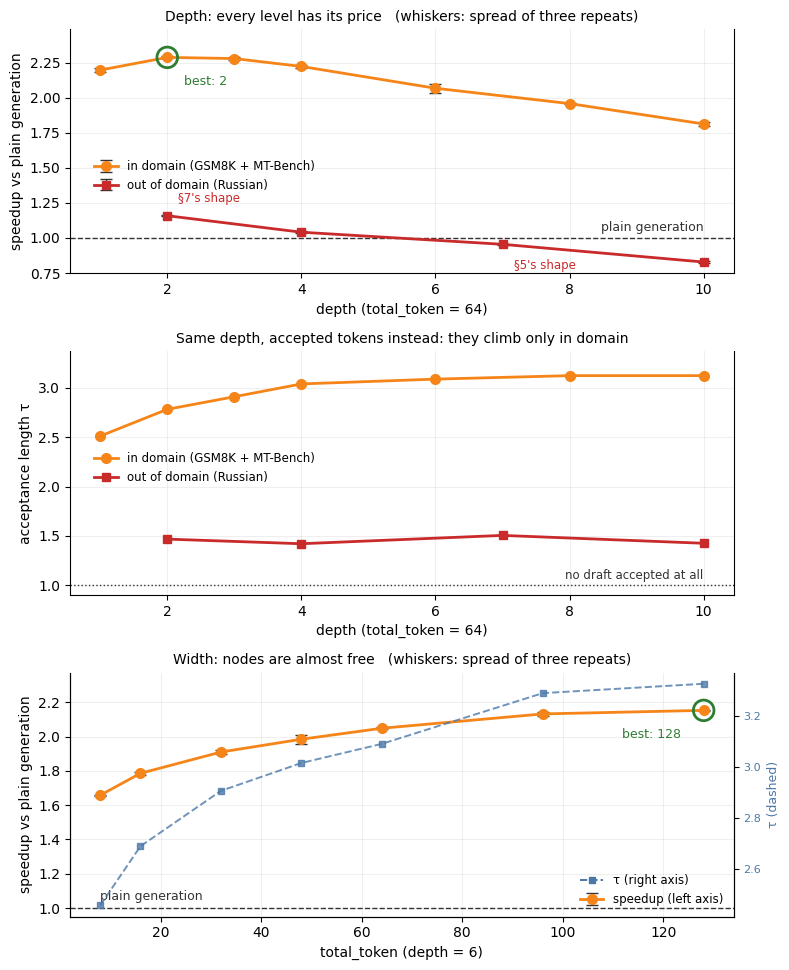

best depth (at total_token = 64): 2
best size  (at depth = 6):        128
τ as the tree grows: 2.46 -> 3.32, as depth grows: 2.51 -> 3.12

combined point 128/2/10: 20.79 ± 0.23 ms/tok | τ 2.84 | speedup 2.25x
it is not better than the best single-sweep points — the knobs interact; taking the best verified configuration


In [22]:
# --- Ablation figure --------------------------------------------------------------
fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.0, 9.8))
ks    = list(depth_res.keys())
ks_ru = list(depth_ru.keys())
C_OUT = "#C92A2A"

# --- panel 1: what depth costs, on both domains -------------------------------------
sp     = np.array([NAIVE_MS / depth_res[k]["ms"] for k in ks])
err    = np.array([NAIVE_MS / depth_res[k]["ms"] * depth_res[k]["ms_std"] / depth_res[k]["ms"] for k in ks])
sp_ru  = np.array([NAIVE_RU / depth_ru[k]["ms"] for k in ks_ru])
err_ru = np.array([NAIVE_RU / depth_ru[k]["ms"] * depth_ru[k]["ms_std"] / depth_ru[k]["ms"] for k in ks_ru])
a1.errorbar(ks, sp, yerr=err, fmt="o-", color=C_EAGLE, lw=2, ms=7, capsize=4,
            ecolor=C_INK, elinewidth=1, label="in domain (GSM8K + MT-Bench)")
a1.errorbar(ks_ru, sp_ru, yerr=err_ru, fmt="s-", color=C_OUT, lw=2, ms=6, capsize=4,
            ecolor=C_INK, elinewidth=1, label="out of domain (Russian)")
a1.axhline(1.0, color=C_INK, lw=1.0, ls="--")
a1.text(ks[-1], 1.03, "plain generation", fontsize=9, color=C_INK, va="bottom", ha="right")
best_k = ks[int(np.argmax(sp))]
a1.scatter([best_k], [max(sp)], s=220, facecolor="none", edgecolor=C_OK, lw=2, zorder=5)
a1.annotate(f"best: {best_k}", (best_k, max(sp)), textcoords="offset points",
            xytext=(12, -20), ha="left", fontsize=9, color=C_OK)
for _d, _lbl, _dy in ((7, "§5's shape", -18), (ks_ru[0], "§7's shape", 10)):
    if _d in depth_ru:
        a1.annotate(_lbl, (_d, NAIVE_RU / depth_ru[_d]["ms"]), textcoords="offset points",
                    xytext=(8, _dy), fontsize=8.5, color=C_OUT)
a1.set_ylim(min(0.78, sp_ru.min() - 0.08), max(sp) + 0.20)
a1.set_ylabel("speedup vs plain generation")
a1.set_title("Depth: every level has its price   (whiskers: spread of three repeats)", fontsize=10)
a1.legend(frameon=False, fontsize=8.5, loc="center left", bbox_to_anchor=(0.02, 0.40))

# --- panel 2: same depth, acceptance length instead ----------------------------------
# This is the section's argument as a picture: in domain tau climbs with depth, off it
# the line is flat. Off-domain depth buys price and no extra accepted tokens.
a2.plot(ks, [depth_res[k]["tau"] for k in ks], "o-", color=C_EAGLE, lw=2, ms=7,
        label="in domain (GSM8K + MT-Bench)")
a2.plot(ks_ru, [depth_ru[k]["tau"] for k in ks_ru], "s-", color=C_OUT, lw=2, ms=6,
        label="out of domain (Russian)")
a2.axhline(1.0, color=C_INK, lw=1.0, ls=":")
a2.text(ks[-1], 1.03, "no draft accepted at all", fontsize=8.5, color=C_INK,
        va="bottom", ha="right")
a2.set_ylim(0.9, max(depth_res[k]["tau"] for k in ks) + 0.25)
a2.set_ylabel("acceptance length τ")
a2.set_title("Same depth, accepted tokens instead: they climb only in domain", fontsize=10)
a2.legend(frameon=False, fontsize=8.5, loc="center left", bbox_to_anchor=(0.02, 0.52))

# --- panel 3: width ------------------------------------------------------------
ksz  = list(size_res.keys())
spz  = np.array([NAIVE_MS / size_res[k]["ms"] for k in ksz])
errz = np.array([NAIVE_MS / size_res[k]["ms"] * size_res[k]["ms_std"] / size_res[k]["ms"] for k in ksz])
a3.errorbar(ksz, spz, yerr=errz, fmt="o-", color=C_EAGLE, lw=2, ms=7, capsize=4,
            ecolor=C_INK, elinewidth=1, label="speedup (left axis)")
a3.axhline(1.0, color=C_INK, lw=1.0, ls="--")
a3.text(ksz[0], 1.03, "plain generation", fontsize=9, color=C_INK, va="bottom", ha="left")
best_z = ksz[int(np.argmax(spz))]
a3.scatter([best_z], [max(spz)], s=220, facecolor="none", edgecolor=C_OK, lw=2, zorder=5)
_rt = best_z >= ksz[len(ksz) // 2]        # near the right edge the label goes left, or it gets clipped
a3.annotate(f"best: {best_z}", (best_z, max(spz)), textcoords="offset points",
            xytext=(-16, -20) if _rt else (12, -20), ha="right" if _rt else "left",
            fontsize=9, color=C_OK)
a3.set_ylim(min(0.95, spz.min() - 0.1), max(spz) + 0.22)
a3z = a3.twinx()
a3z.plot(ksz, [size_res[k]["tau"] for k in ksz], "s--", color=C_NAIVE, lw=1.4, ms=5, alpha=0.8)
a3z.set_ylabel("τ (dashed)", color=C_NAIVE, fontsize=9)
a3z.tick_params(axis="y", labelcolor=C_NAIVE, labelsize=8)
a3z.spines[["top"]].set_visible(False)
a3.plot([], [], "s--", color=C_NAIVE, lw=1.4, ms=5, label="τ (right axis)")
a3.set_ylabel("speedup vs plain generation")
a3.set_title("Width: nodes are almost free   (whiskers: spread of three repeats)", fontsize=10)
a3.legend(frameon=False, fontsize=8.5, loc="lower right")

for _ax, _xl in ((a1, "depth (total_token = 64)"), (a2, "depth (total_token = 64)"),
                 (a3, "total_token (depth = 6)")):
    _ax.set_xlabel(_xl)
    _ax.spines[["top"]].set_visible(False)
    _ax.grid(alpha=0.2)
finish("ablation")

BEST_DEPTH = min(depth_res, key=lambda k: depth_res[k]["ms"])
BEST_SIZE  = min(size_res,  key=lambda k: size_res[k]["ms"])
print(f"best depth (at total_token = 64): {BEST_DEPTH}")
print(f"best size  (at depth = 6):        {BEST_SIZE}")
print(f"τ as the tree grows: {size_res[SIZES_T[0]]['tau']:.2f} -> {size_res[SIZES_T[-1]]['tau']:.2f}, "
      f"as depth grows: {depth_res[DEPTHS[0]]['tau']:.2f} -> {depth_res[DEPTHS[-1]]['tau']:.2f}")

# Each sweep found its optimum at the other knob's foreign value, so the combined
# point must be verified separately, not declared best by construction.
combo = measure_tree(BEST_SIZE, BEST_DEPTH, 10)
print(f"\ncombined point {BEST_SIZE}/{BEST_DEPTH}/10: {combo['ms']:.2f} ± {combo['ms_std']:.2f} ms/tok "
      f"| τ {combo['tau']:4.2f} | speedup {NAIVE_MS/combo['ms']:.2f}x")
best_single = min(depth_res[BEST_DEPTH]["ms"], size_res[BEST_SIZE]["ms"])
print("it is " + ("better" if combo["ms"] < best_single else "not better") +
      " than the best single-sweep points — "
      + ("the knobs compose" if combo["ms"] < best_single
         else "the knobs interact; taking the best verified configuration"))


> **Takeaway.** The two sweeps behave differently, and exactly as the arithmetic of [§1](#s1) predicts. Depth has a clear optimum past which it only hurts: acceptance length plateaus while time keeps growing with every extra draft-model launch. Width is nearly free while the pass stays flat, so its curve climbs to a ceiling instead of collapsing.

The red line on the top panel is the same depth sweep on the out-of-domain set, and it explains [§5](#s5)'s slowdown. The middle panel shows why: acceptance length there stays flat, near one and a half at every depth, while in domain it climbs with every level. Off its own domain the draft guesses just as rarely at two levels as at ten. So depth buys nothing there but price, and on a deep tree the price wins: the top curve crosses under 1.0. So [§5](#s5), which measures at the deep starting shape, finds a slowdown, while at the shallow shape picked here the same prompts come out slightly ahead. Domain decides how much the method can win; depth decides how much it can lose, sign included.

The shallow depths are separated by a couple of percent, which is about the drift between whole sessions — and across runs of this notebook the winner has moved between depth 2 and depth 3 while the shape of both curves stayed put. So read the sweep for its shape, not for whichever point came out best: what it establishes is what the deep default costs: about 10%. Which of the shallow depths wins it does not settle.

The library ships a mode that picks the tree size on its own. Comparing its choice with the sweeps above.

In [23]:
# --- What the authors' auto-pick heuristic would choose ---------------------------
# EaModel.from_pretrained has a total_token=-1 mode: it times a target pass at
# lengths 40..60, divides by heuristic weights and takes the minimum.
CANDS, WEIGHTS = [40, 48, 50, 56, 60], [1, 1.05, 1.07, 1.1, 1.13]
scores = []
with torch.no_grad():
    for n, w in zip(CANDS, WEIGHTS):
        ids = torch.randint(0, cfg.vocab_size - 200, (1, n)).cuda()
        for _ in range(3):
            plain_forward(ids)
        t = float(np.median([timed(plain_forward, ids)[1] for _ in range(7)]))
        scores.append(t / w)
auto_pick = CANDS[int(np.argmin(scores))]
print(f"the authors' auto-pick would choose total_token = {auto_pick}")
print(f"our width sweep peaks near {BEST_SIZE}, but it runs at depth 6 — and at the depth")
print(f"this section actually picks ({BEST_DEPTH}), width saturates far earlier: the combined")
print(f"point {BEST_SIZE}/{BEST_DEPTH}/10 is measured against the single-sweep winners below,")
print("and the knobs turn out to interact.")
print(f"\nThe gap that matters is the knob the heuristic never turns. It searches total_token")
print(f"in {CANDS[0]}..{CANDS[-1]} and leaves depth fixed, while on this card depth is what costs:")
print("every level adds a sequential draft launch, and acceptance plateaus by level four.")

if combo["ms"] <= best_single:
    MAIN_TREE = dict(total_token=int(BEST_SIZE), depth=int(BEST_DEPTH), top_k=10)
elif depth_res[BEST_DEPTH]["ms"] <= size_res[BEST_SIZE]["ms"]:
    MAIN_TREE = dict(total_token=64, depth=int(BEST_DEPTH), top_k=10)
else:
    MAIN_TREE = dict(total_token=int(BEST_SIZE), depth=6, top_k=10)
set_tree(**MAIN_TREE)
print(f"\nProceeding with the tree {MAIN_TREE}")


the authors' auto-pick would choose total_token = 60
our width sweep peaks near 128, but it runs at depth 6 — and at the depth
this section actually picks (2), width saturates far earlier: the combined
point 128/2/10 is measured against the single-sweep winners below,
and the knobs turn out to interact.

The gap that matters is the knob the heuristic never turns. It searches total_token
in 40..60 and leaves depth fixed, while on this card depth is what costs:
every level adds a sequential draft launch, and acceptance plateaus by level four.

Proceeding with the tree {'total_token': 64, 'depth': 2, 'top_k': 10}


> **Takeaway.** The authors' auto-pick tunes the one knob that does not decide anything here. It searches node count in the range 40–60 and never touches depth — and depth is what costs on this card: the shape this section settles on carries 64 nodes, a mere four above the heuristic's ceiling, while dropping depth from the loaded default is worth about 10%. The width sweep's own optimum sits far higher than either, but it is measured at depth 6 and does not survive the move to a shallow tree — the combined point printed above lost to the winner of the depth sweep. The heuristic was tuned on other models and other hardware — exactly the case where a borrowed setting should be re-measured, not inherited.

<a id="s8"></a>
## 8. Where the cycle spends its time

A cycle has four phases: drafting (sequential head passes), verification (one target pass over the whole tree), path selection, and everything else — cache copying, building the next tree, host-side bookkeeping.

Synchronizing wrappers cost time themselves, so "everything else" is not computed by subtraction alone: the same run is timed again without instrumentation, and the difference between the two runs is the price of measuring — shown, not hidden.

Wrapping the three phases in timers and running twice: instrumented and clean.

In [24]:
# --- The cycle, split into phases --------------------------------------------------
import eagle.model.ea_model as ea_mod

PHASE_Q = encode(BENCH["MT-Bench"][0])
clean = run_eagle(PHASE_Q, N_TOK)            # the clean reference, no instrumentation

acc_t = {"drafting": 0.0, "verification": 0.0, "path selection": 0.0}
def wrap(fn, key):
    def w(*a, **k):
        torch.cuda.synchronize(); t = time.perf_counter()
        r = fn(*a, **k)
        torch.cuda.synchronize(); acc_t[key] += time.perf_counter() - t
        return r
    return w

orig_topk = model.ea_layer.topK_genrate
orig_td, orig_ep = ea_mod.tree_decoding, ea_mod.evaluate_posterior
model.ea_layer.topK_genrate = wrap(orig_topk, "drafting")
ea_mod.tree_decoding = wrap(orig_td, "verification")
ea_mod.evaluate_posterior = wrap(orig_ep, "path selection")
inst = run_eagle(PHASE_Q, N_TOK)
model.ea_layer.topK_genrate = orig_topk
ea_mod.tree_decoding, ea_mod.evaluate_posterior = orig_td, orig_ep

steps = inst["steps"]
parts = {k: 1000 * v / steps for k, v in acc_t.items()}
cycle_ms = 1000 * inst["sec"] / steps
parts["everything else"] = cycle_ms - sum(parts.values())
clean_cycle = 1000 * clean["sec"] / clean["steps"]

print(f"cycle (instrumented): {cycle_ms:.1f} ms, yields τ = {inst['tokens']/steps:.2f}")
print(f"cycle (clean):        {clean_cycle:.1f} ms  <- measurement overhead "
      f"{cycle_ms - clean_cycle:.1f} ms")
for k, v in parts.items():
    print(f"   {k:16s} {v:5.1f} ms ({100*v/cycle_ms:4.1f}%)")
print(f"\nplain step: {NAIVE_MS:.1f} ms per token")
print(f"verifying a {MAIN_TREE['total_token']}-node tree: {parts['verification']:.1f} ms "
      f"= {parts['verification']/NAIVE_MS:.2f} of a plain step")
print(f"and the §1 target pass at {MAIN_TREE['total_token']} tokens: "
      f"{roof[min(SIZES, key=lambda s: abs(s-MAIN_TREE['total_token']))]:.1f} ms — they agree")


cycle (instrumented): 56.4 ms, yields τ = 2.52
cycle (clean):        56.3 ms  <- measurement overhead 0.1 ms
   drafting           9.0 ms (16.0%)
   verification      45.6 ms (80.9%)
   path selection     0.4 ms ( 0.7%)
   everything else    1.4 ms ( 2.5%)

plain step: 46.8 ms per token
verifying a 64-node tree: 45.6 ms = 0.97 of a plain step
and the §1 target pass at 64 tokens: 47.7 ms — they agree


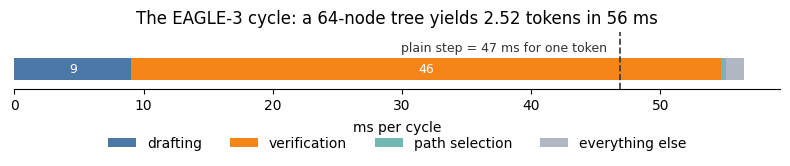

In [25]:
# --- Phase figure -----------------------------------------------------------------
PH_COLORS = {"drafting": C_NAIVE, "verification": C_EAGLE,
             "path selection": "#72B7B2", "everything else": "#B0B7C3"}
fig, ax = plt.subplots(figsize=(8.0, 2.7))
left = 0
for k, v in parts.items():
    ax.barh([0], [v], left=left, height=0.5, color=PH_COLORS[k], label=k)
    if v > 4:
        ax.text(left + v / 2, 0, f"{v:.0f}", ha="center", va="center", fontsize=9, color="white")
    left += v
ax.axvline(NAIVE_MS, color=C_INK, lw=1.2, ls="--")
ax.text(NAIVE_MS - 1, 0.48, f"plain step = {NAIVE_MS:.0f} ms for one token",
        fontsize=9, color=C_INK, ha="right", va="center")
ax.set_xlabel("ms per cycle", labelpad=6); ax.set_yticks([]); ax.set_ylim(-0.45, 0.85)
ax.set_title(f"The EAGLE-3 cycle: a {MAIN_TREE['total_token']}-node tree yields "
             f"{inst['tokens']/steps:.2f} tokens in {cycle_ms:.0f} ms")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.62))
ax.spines[["top", "right", "left"]].set_visible(False)
finish("cycle_phases")


> **Takeaway.** Verification takes about 80% of the cycle and costs almost exactly what a plain step costs for a single token — except it brings back two and a half, the tree now in the shape [§7](#s7) selected — the figure title above names it. The draft model takes about 15%, and path selection together with cache copying comes to a couple of percent. Same price, more product.

<a id="s9"></a>
## 9. Temperature: where the method's main guarantee is tested

The other half of the promise is that the method spoils nothing.

Under greedy decoding "no quality loss" is nearly a tautology: only a draft matching the target's `argmax` gets accepted. The substantive guarantee is stated for sampling: speculative decoding must produce exactly the same distribution as ordinary sampling from the target model.

Precision matters here, because the repository's implementation differs from the classic papers. In [Leviathan](https://arxiv.org/abs/2211.17192) and [Chen](https://arxiv.org/abs/2302.01318), a draft is accepted with probability $\min(1,\, p/q)$, where $p$ is the target's probability and $q$ the draft's, and on rejection one samples from the normalized difference. The EAGLE code (`evaluate_posterior`, the `logits_processor` branch) sets `qx = 1.0`: a candidate is accepted with probability p(x); on rejection p(x) is zeroed out, the distribution renormalized, and the next unique candidate from the tree is tried.

This scheme is unbiased too, and one line shows it. The probability that candidate $a$ is rejected and token $b$ lands in its place is

$$\bigl(1 - p(a)\bigr)\cdot\frac{p(b)}{1 - p(a)} = p(b)$$

The first factor is the probability of rejecting the candidate, the second of picking $b$ from the renormalized distribution; the rejection factor cancels against the normalization. Induction over candidates extends this to any number of them, so the final distribution equals p under any proposal strategy: the draft model affects speed, never the outcome.

The proof lives in exact arithmetic. In fp16, tree logits and single-token logits are computed in different operation orders and need not agree bit for bit. So both things get measured: whether the distributions match, and by how much the logits actually drift.

Running the same prompts at four temperatures, watching acceptance length and speed.

T=0.0: τ 2.76 | 20.66 ms/tok | speedup 2.27x
T=0.3: τ 2.89 | 21.05 ms/tok | speedup 2.23x
T=0.7: τ 2.70 | 22.21 ms/tok | speedup 2.11x
T=1.0: τ 2.93 | 20.96 ms/tok | speedup 2.24x


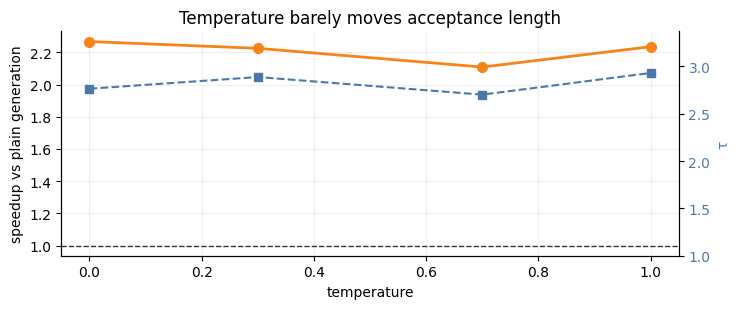

In [26]:
# --- τ and speed vs temperature ---------------------------------------------------
TEMPS = [0.0, 0.3, 0.7, 1.0]
T_Q = [BENCH["GSM8K"][0], BENCH["MT-Bench"][0]]
T_TOK = 96 if QUICK else 160

temp_rows = []
for T in TEMPS:
    ms, taus = [], []
    for q in T_Q:
        ids = encode(q)
        with NoEOS():
            (_, new, idx), dt = timed(model.eagenerate, ids, temperature=T,
                                      top_k=0, top_p=0.0, max_new_tokens=T_TOK, log=True)
        ms.append(1000 * dt / int(new)); taus.append(int(new) / (idx + 1))
    temp_rows.append(dict(T=T, ms=float(np.mean(ms)), tau=float(np.mean(taus)),
                          speedup=NAIVE_MS / float(np.mean(ms))))
    print(f"T={T:3.1f}: τ {temp_rows[-1]['tau']:4.2f} | "
          f"{temp_rows[-1]['ms']:5.2f} ms/tok | speedup {temp_rows[-1]['speedup']:4.2f}x")

td = pd.DataFrame(temp_rows)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(td["T"], td["speedup"], "o-", color=C_EAGLE, lw=2, ms=7, label="speedup")
ax.axhline(1.0, color=C_INK, lw=1.0, ls="--")
ax2 = ax.twinx()
ax2.plot(td["T"], td["tau"], "s--", color=C_NAIVE, lw=1.5, ms=6, label="τ")
ax2.set_ylabel("τ", color=C_NAIVE); ax2.tick_params(axis="y", labelcolor=C_NAIVE)
# baseline τ = 1 (plain generation): otherwise autoscale inflates noise into a trend
ax2.set_ylim(1.0, max(td["tau"]) * 1.15)
ax.set_xlabel("temperature"); ax.set_ylabel("speedup vs plain generation")
ax.set_title("Temperature barely moves acceptance length")
ax.spines[["top"]].set_visible(False); ax2.spines[["top"]].set_visible(False)
ax.grid(alpha=0.2)
finish("temperature")


> **Takeaway.** The expectation was: hotter sampling, rarer draft hits, smaller gain. The authors confirm it — for LLaMA-3.1-8B they report 4.44× at T = 0 against 3.45× at T = 1, roughly a fifth lost. My measurement shows no such drop: acceptance length and speedup wander within a few percent with no clear trend. I would not call that a refutation — this is two prompts without repeats, a target almost five times smaller, and shorter generations, so the sensitivity may simply not be there. What can be claimed: full sampling causes no collapse, and the method stays roughly twice as fast as plain generation.

Collecting 500 independent continuations per loop. Their random-seed ranges differ on purpose: the samples must be independent, or the comparison becomes paired and shows agreement where there is none.

In [27]:
# --- Empirical check: do the distributions match at T = 1 -------------------------
import random as _random

DIST_PROMPT = "List five random English nouns, comma-separated. Words only, no explanation."
K_TOK = 5                                  # how many leading tokens to compare
M = 200 if QUICK else 500                  # samples per loop
dist_ids = encode(DIST_PROMPT)

def sample_prefixes(fn, m, seed0):
    """m independent continuations of length K_TOK at temperature 1."""
    out = []
    for i in range(m):
        # accept/reject uses random.random(), token draws use torch: seed both
        torch.manual_seed(seed0 + i); _random.seed(seed0 + i)
        with NoEOS():
            res = fn(dist_ids, temperature=1.0, top_k=0, top_p=0.0,
                     max_new_tokens=K_TOK + 1, log=True)
        g = res[0][0, dist_ids.shape[1]:].tolist()
        if len(g) >= K_TOK:
            out.append(tuple(g[:K_TOK]))
    return out

t0 = time.time()
# Seed ranges differ: samples must be independent, or the comparison is paired
ea_s  = sample_prefixes(model.eagenerate,    M,  50_000)
nv_s  = sample_prefixes(model.naivegenerate, M,  90_000)
nv2_s = sample_prefixes(model.naivegenerate, M, 300_000)   # the control sample
print(f"collected in {time.time()-t0:.0f} s: EAGLE {len(ea_s)}, plain {len(nv_s)}, "
      f"control {len(nv2_s)}")


collected in 500 s: EAGLE 500, plain 500, control 500


Statistics are easy to ruin here, so a word about the test.

Comparing empirical distributions by total variation distance (TV) is not enough on its own: two finite samples from the very same distribution still have TV above zero, and the wider the support, the larger it gets. What is needed is a null band — how much TV accrues merely because samples are finite.

Building that band by bootstrapping the observed sample is a trap: resampling from a pool produces more coincidences than two genuinely independent draws, the band comes out too narrow, and the test declares any difference significant. The right tool is a **permutation test**: if the distributions match, the sample labels are exchangeable, so shuffling labels across the pooled samples yields an exact null with no assumptions about the support.

And to avoid judging the test's health by the very data it checks, a control runs alongside: two independent samples of plain generation. The test must find no difference there.

In [28]:
# --- Permutation test for equality of distributions -------------------------------
def tv(a, b):
    ca, cb = Counter(a), Counter(b)
    return 0.5 * sum(abs(ca[k]/len(a) - cb[k]/len(b)) for k in set(ca) | set(cb))

_rng = np.random.default_rng(0)

def perm_test(a, b, reps=1500):
    """Returns observed TV, the null's 95th percentile, the p-value and the null draw."""
    obs = tv(a, b)
    pool = list(a) + list(b)
    na, idx = len(a), np.arange(len(a) + len(b))
    null = np.empty(reps)
    for r in range(reps):
        _rng.shuffle(idx)
        null[r] = tv([pool[i] for i in idx[:na]], [pool[i] for i in idx[na:]])
    return obs, float(np.percentile(null, 95)), float((null >= obs).mean()), null

print("CONTROL — plain vs plain (the test must find NO difference):")
c_obs, c_thr, c_p, c_null = perm_test(nv_s, nv2_s)
print(f"  joint distribution of {K_TOK} tokens: TV={c_obs:.4f}, "
      f"threshold={c_thr:.4f}, p={c_p:.3f}  "
      f"{'test is healthy' if c_p > 0.05 else 'TEST IS BROKEN — stop here'}")

print("\nTEST — EAGLE vs plain:")
obs, thr, pval, null = perm_test(ea_s, nv_s)
print(f"  joint distribution of {K_TOK} tokens: TV={obs:.4f}, "
      f"threshold={thr:.4f}, p={pval:.3f}")
print(f"  distinct sequences: plain {len(set(nv_s))}, EAGLE {len(set(ea_s))}")
print(f"  VERDICT: {'distributions indistinguishable' if pval > 0.05 else 'difference found'}")

print("\nper position (position 0 is drawn straight from the target's logits,")
print("positions 1 and later pass through speculative accept/reject):")
for j in range(K_TOK):
    o, t_, p_, _ = perm_test([x[j] for x in ea_s], [x[j] for x in nv_s], reps=600)
    oc, tc, pc, _ = perm_test([x[j] for x in nv_s], [x[j] for x in nv2_s], reps=600)
    sup = len(set(x[j] for x in nv_s))
    print(f"  pos {j}: EAGLE p={p_:.3f} {'ok' if p_ > 0.05 else '!!'} | "
          f"control p={pc:.3f} | distinct tokens {sup}")


CONTROL — plain vs plain (the test must find NO difference):
  joint distribution of 5 tokens: TV=0.1440, threshold=0.1940, p=0.865  test is healthy

TEST — EAGLE vs plain:
  joint distribution of 5 tokens: TV=0.2060, threshold=0.2060, p=0.053
  distinct sequences: plain 65, EAGLE 65
  VERDICT: distributions indistinguishable

per position (position 0 is drawn straight from the target's logits,
positions 1 and later pass through speculative accept/reject):
  pos 0: EAGLE p=0.033 !! | control p=0.827 | distinct tokens 10
  pos 1: EAGLE p=0.528 ok | control p=0.410 | distinct tokens 3
  pos 2: EAGLE p=0.003 !! | control p=0.192 | distinct tokens 12
  pos 3: EAGLE p=0.498 ok | control p=0.482 | distinct tokens 11
  pos 4: EAGLE p=0.118 ok | control p=0.507 | distinct tokens 16


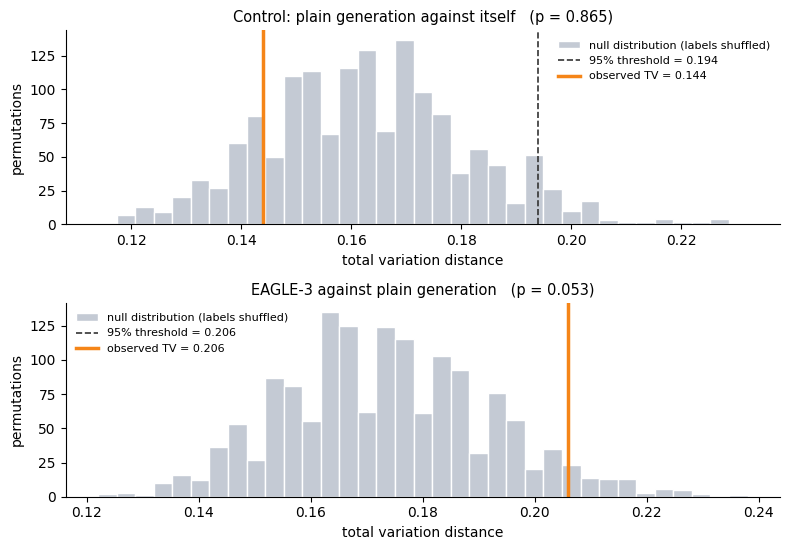

first-token frequencies (plain | control | EAGLE):
         'book':  174 |  174 |  160
        'apple':  137 |  141 |  180
          'dog':   72 |   83 |   65
          'cat':   68 |   60 |   51
          'car':   35 |   27 |   29
         'bird':    6 |    4 |    6
         'tree':    3 |    6 |    4
         'door':    3 |    2 |    1


In [29]:
# --- Figure: observed TV against the null distribution ----------------------------
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.0, 5.6))
for ax, nl, o, th, p, ttl in (
        (a1, c_null, c_obs, c_thr, c_p, "Control: plain generation against itself"),
        (a2, null,   obs,   thr,   pval, "EAGLE-3 against plain generation")):
    ax.hist(nl, bins=35, color=C_GRID, edgecolor="white",
            label="null distribution (labels shuffled)")
    ax.axvline(th, color=C_INK, lw=1.2, ls="--", label=f"95% threshold = {th:.3f}")
    ax.axvline(o, color=C_EAGLE, lw=2.5, label=f"observed TV = {o:.3f}")
    ax.set_title(f"{ttl}   (p = {p:.3f})", fontsize=10.5)
    ax.set_xlabel("total variation distance")
    ax.set_ylabel("permutations")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
finish("losslessness_t1")

print("first-token frequencies (plain | control | EAGLE):")
c1, c2, c3 = (Counter(x[0] for x in nv_s), Counter(x[0] for x in nv2_s),
              Counter(x[0] for x in ea_s))
for k, v in c1.most_common(8):
    print(f"   {tok.decode([k])!r:>12}: {v:4d} | {c2[k]:4d} | {c3[k]:4d}")


> **Takeaway.** Top panel, the control: two independent samples of plain generation, and the test finds no difference — so it is not inclined to see gaps where there are none. Bottom panel, the EAGLE comparison: the observed distance sits inside the same null distribution. It sits tight, though — p comes out near the boundary, and this test leaves no margin. The question is settled not by it but by the direct distribution comparison below.

### Where the residual difference comes from

The joint test finds no difference, yet two positions out of five come back with low p. Before declaring the guarantee broken, consider position 0: the first new token is drawn straight from the target's logits in both loops — the speculative accept plays no part in it. If a difference exists already there, its source is arithmetic, not the acceptance rule.

This can be checked exactly, no statistics: intercept the probability tensor each loop draws its first token from and compare the two distributions head-on.

The cell below hooks the token draw and prints both probability tables side by side.

In [30]:
# --- Intercept: which distributions the first token is drawn from -----------------
captured = {}
_tag = ["?"]
_orig_multinomial = torch.multinomial

def _capturing_multinomial(input, num_samples, *a, **kw):
    if _tag[0] not in captured:                       # only the very first call
        captured[_tag[0]] = input.detach().float().cpu().clone().flatten()
    return _orig_multinomial(input, num_samples, *a, **kw)

torch.multinomial = _capturing_multinomial
try:
    # not `for name, fn in (... model.eagenerate ...)`: the bound method outlives the loop
    # as a global and keeps the whole model alive, so §11 cannot unload it
    for name, _meth in (("eagle", "eagenerate"), ("naive", "naivegenerate")):
        _tag[0] = name
        torch.manual_seed(0); _random.seed(0)
        with NoEOS():
            getattr(model, _meth)(dist_ids, temperature=1.0, top_k=0,
                                  top_p=0.0, max_new_tokens=1, log=True)
finally:
    torch.multinomial = _orig_multinomial

p_ea, p_nv = captured["eagle"], captured["naive"]
delta = (p_ea - p_nv).abs()
tv_direct = 0.5 * float(delta.sum())
print(f"vocabulary size: {p_ea.numel()}")
print(f"TV between the first-token distributions: {tv_direct:.5f}")
print(f"largest single-token probability difference: {float(delta.max()):.5f}")
print(f"bit-for-bit identical: {bool(torch.equal(p_ea, p_nv))}")

top = torch.topk(p_nv, 8).indices
print("")
print(f"{'token':>12} {'plain':>9} {'EAGLE':>9} {'delta':>9}")
for t in top.tolist():
    print(f"{tok.decode([t])!r:>12} {float(p_nv[t]):9.5f} {float(p_ea[t]):9.5f} "
          f"{float(p_ea[t]-p_nv[t]):+9.5f}")
print("")
if tv_direct > 1e-6:
    print("The distributions differ BEFORE the speculative accept even engages:")
    print("the first token comes straight from the target's logits in both loops. So the")
    print("source is not the acceptance rule but fp16 operation order: the speculative")
    print("loop computes logits over the whole tree at once, the plain one per position.")
    print("The same effect shows at T = 0 in §10, where it only surfaces at spots")
    print("with two nearly indistinguishable candidates.")
else:
    print("The distributions match bit for bit — the residual difference in the test")
    print("above is explained by finite samples and multiple comparisons.")


vocabulary size: 151936
TV between the first-token distributions: 0.00000
largest single-token probability difference: 0.00000
bit-for-bit identical: True

       token     plain     EAGLE     delta
     'apple'   0.33350   0.33350  +0.00000
      'book'   0.31812   0.31812  +0.00000
       'dog'   0.15259   0.15259  +0.00000
       'cat'   0.11169   0.11169  +0.00000
       'car'   0.05792   0.05792  +0.00000
      'tree'   0.01072   0.01072  +0.00000
      'bird'   0.00714   0.00714  +0.00000
      'door'   0.00302   0.00302  +0.00000

The distributions match bit for bit — the residual difference in the test
above is explained by finite samples and multiple comparisons.


<a id="s10"></a>
## 10. Matching plain generation at T = 0

Back to greedy mode, where the requirement is stricter: not the distribution but the sequence itself must match. EAGLE must produce the exact same token chain as the plain loop. The outputs are compared token by token — and if divergences turn up, I measure how large they are and where they arise.

The hypothesis is simple. A plain step processes one token; a speculative step, a tree of dozens — different tensor shapes, different CUDA kernels, different fp16 summation order. If at some position the two best candidates are nearly tied in logit, summation order decides the outcome. So at divergence points the top-1/top-2 gap should be anomalously small compared to ordinary positions. That is a testable prediction, and easy to refute: if the gaps at divergence points look ordinary, the cause is the implementation, not numerics.

Comparing the two outputs token by token across ten prompts.

In [31]:
# --- Token-by-token comparison at T = 0 (EOS stopping on, as in real use) ---------
CHECK = [(b, q) for b in BENCH for q in BENCH[b][:2]]
CHECK_TOK = 128 if QUICK else 256

diffs, checked = [], []
for bench_name, q in CHECK:
    ids = encode(q)
    (o_nv, n_nv, _), _ = timed(model.naivegenerate, ids, temperature=0.0,
                               max_new_tokens=CHECK_TOK, log=True)
    (o_ea, n_ea, _), _ = timed(model.eagenerate, ids, temperature=0.0,
                               max_new_tokens=CHECK_TOK, log=True)
    a = o_ea[0, ids.shape[1]:].tolist()
    b = o_nv[0, ids.shape[1]:].tolist()
    m = 0
    for x, y in zip(a, b):
        if x != y:
            break
        m += 1
    checked.append(dict(bench=bench_name, q=q, n=min(len(a), len(b)), match=m,
                        prefix=b[:m], ea=a, nv=b, ids=ids))
    if m < min(len(a), len(b)):
        diffs.append(checked[-1])

tot_tokens = sum(c["n"] for c in checked)
print(f"checked {len(checked)} prompts, {tot_tokens} tokens")
print(f"perfect match: {len(checked)-len(diffs)} of {len(checked)} prompts")
print(f"divergences: {len(diffs)} = {1000*len(diffs)/tot_tokens:.2f} per 1000 tokens")


checked 10 prompts, 2219 tokens
perfect match: 6 of 10 prompts
divergences: 4 = 1.80 per 1000 tokens


Now the hypothesis itself: take the positions where outputs diverged and look at the gap between the target's two best candidates, with the same gap on matching positions as the background.

prompt: MT-Bench — 'Compose an engaging travel blog post about a recent trip to '
178 tokens matched, then diverged
  plain: ' left me in tears of appreciation.\n\nI'
  EAGLE: ' truly brought me into the heart of Hawaiian'

top1-top2 gap at the divergence point: 0.0000
median gap at matching positions:      2.8359
divergence point's percentile in the background: 0%


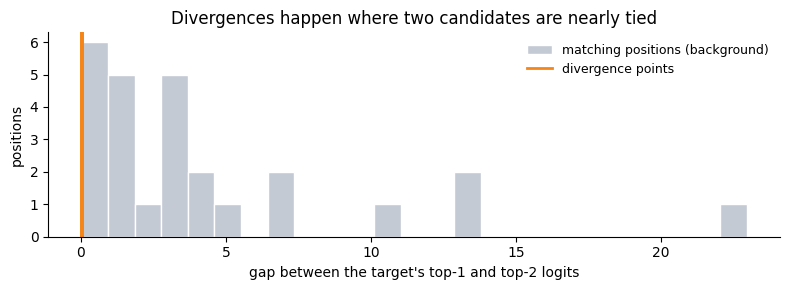


Conclusion: the gaps at divergence points hug zero while an ordinary
position is confidently separated. This is exactly the picture the fp16
summation-order hypothesis predicts, not a flaw in the acceptance rule:
the losslessness guarantee is stated for exact arithmetic.


In [32]:
# --- Forensics: how close the logits are at divergence points ---------------------
@torch.no_grad()
def top2_gap(ids, prefix):
    """Gap between the target's two best logits after a given prefix."""
    full = torch.cat([ids, torch.tensor([prefix], device=ids.device, dtype=torch.long)], dim=1) \
           if prefix else ids
    logits = plain_forward(full).logits[0, -1].float()
    top = torch.topk(logits, 2).values
    return float(top[0] - top[1])

if diffs:
    d = diffs[0]
    gap_at_div = top2_gap(d["ids"], d["prefix"])
    # background: gaps at positions where both outputs agreed
    step = max(1, len(d["prefix"]) // 25)
    background = [top2_gap(d["ids"], d["prefix"][:k])
                  for k in range(1, max(2, len(d["prefix"])), step)]
    all_gaps = [top2_gap(x["ids"], x["prefix"]) for x in diffs]

    print(f"prompt: {d['bench']} — {d['q'][:60]!r}")
    print(f"{d['match']} tokens matched, then diverged")
    print(f"  plain: {tok.decode(d['nv'][d['match']:d['match']+8])!r}")
    print(f"  EAGLE: {tok.decode(d['ea'][d['match']:d['match']+8])!r}")
    print(f"\ntop1-top2 gap at the divergence point: {gap_at_div:.4f}")
    print(f"median gap at matching positions:      {np.median(background):.4f}")
    print(f"divergence point's percentile in the background: "
          f"{100*np.mean([g <= gap_at_div for g in background]):.0f}%")

    fig, ax = plt.subplots(figsize=(8.0, 3.0))
    ax.hist(background, bins=25, color=C_GRID, edgecolor="white",
            label="matching positions (background)")
    for i, g in enumerate(all_gaps):
        ax.axvline(g, color=C_EAGLE, lw=2,
                   label="divergence points" if i == 0 else None)
    ax.set_xlabel("gap between the target's top-1 and top-2 logits")
    ax.set_ylabel("positions")
    ax.set_title("Divergences happen where two candidates are nearly tied")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    finish("divergence_gaps")
    print("\nConclusion: the gaps at divergence points hug zero while an ordinary")
    print("position is confidently separated. This is exactly the picture the fp16")
    print("summation-order hypothesis predicts, not a flaw in the acceptance rule:")
    print("the losslessness guarantee is stated for exact arithmetic.")
else:
    print("no divergences found — every checked prompt matched token for token")


> **Takeaway.** The hypothesis was falsifiable: if divergences come from numerical noise, they have to fall on positions where two candidates are nearly indistinguishable. So they did — the divergence points hug zero while an ordinary position keeps a confident margin. A consequence of fp16 summation order, not a defect of the acceptance rule.

<a id="scaling"></a>
## 11. The same method, a bigger target

The formula suggests a prediction this notebook has not tested yet. The usual reasoning goes: a draft head is small and roughly fixed in cost, while the target's step grows with model size, so the same method should pay better on a bigger target. That reasoning is checkable, and the check is worth running before repeating it. Qwen3-4B is the largest pair that fits a free T4 in fp16 (8B weighs 16.4 GB, more than the card holds). In the other direction there is simply nothing to compare against: AngelSlim publishes no head for Qwen3-0.6B, so 1.7B is the small end of what can be measured here rather than a floor I picked.

So: the 1.7B pair is re-measured on a small subset at the tree shape [§7](#s7) picked, then leaves the GPU entirely; the 4B pair loads from its own attached models and runs the same subset, same tree, same equal-work rules.

Before the numbers, one thing about the run itself. The official repository cannot load this head as published: Qwen3-4B's attention is wider than its hidden size (32 heads × 128 = 4096 against 2560), while the official draft code derives head width from the hidden size alone. The environment cell patches three lines of `cnets.py` to honor the config's `head_dim` — a no-op for the 1.7B pair and the only modification to the official code in this notebook.


In [33]:
# --- Scaling probe: 1.7B pair vs 4B pair, one protocol ----------------------------
SCALE_SWEEP = not QUICK
SCALING = None
if SCALE_SWEEP:
    SC_Q = BENCH["GSM8K"][:3] + BENCH["MT-Bench"][:3]
    SC_RU = BENCH[LANG_SET][:3]
    SC_TOK = 160

    def pair_numbers():
        """naive ms/tok, eagle ms/tok and τ per subset, averaged over REPS repeats.
        Repeated for the same reason as the ablation in §7: the gaps this section
        argues about are a few percent wide, and one pass cannot separate them
        from drift. Whiskers on the figure are the half-range across passes."""
        out = {}
        for tag, qs in (("in", SC_Q), ("out", SC_RU)):
            nv_r, ea_r, tau_r = [], [], []
            for _ in range(REPS):
                nv = [ms_per_token(run_naive(encode(q), SC_TOK)) for q in qs]
                ea, taus = [], []
                for q in qs:
                    r = run_eagle(encode(q), SC_TOK)
                    ea.append(ms_per_token(r)); taus.append(r["tokens"] / r["steps"])
                nv_r.append(float(np.mean(nv))); ea_r.append(float(np.mean(ea)))
                tau_r.append(float(np.mean(taus)))
            sp_r = [a / b for a, b in zip(nv_r, ea_r)]
            half = lambda v: float((max(v) - min(v)) / 2)
            out[tag] = dict(naive_ms=float(np.mean(nv_r)), eagle_ms=float(np.mean(ea_r)),
                            tau=float(np.mean(tau_r)), speedup=float(np.mean(sp_r)),
                            tau_err=half(tau_r), speedup_err=half(sp_r), reps=REPS)
        return out

    set_tree(**MAIN_TREE)
    with torch.no_grad():
        run_eagle(WARM, 32)
    m17 = pair_numbers()
    print(f"1.7B pair at {MAIN_TREE}:")
    for tag in ("in", "out"):
        d = m17[tag]
        print(f"  {tag:3s}: naive {d['naive_ms']:5.1f} ms/tok | eagle {d['eagle_ms']:5.1f} "
              f"| τ {d['tau']:4.2f} ±{d['tau_err']:.2f} | speedup {d['speedup']:4.2f}x "
              f"±{d['speedup_err']:.2f} over {d['reps']} repeats")

    # the 4B pair needs the whole card: drop everything holding the 1.7B pair
    # (hf was deleted in §5; ea and orig_topk from §3/§8 still hold the draft head)
    for _n in ("model", "ea", "orig_topk", "fn"):
        globals().pop(_n, None)
    gc.collect(); torch.cuda.empty_cache()
    _left = torch.cuda.memory_allocated() / 2**30
    print(f"\nGPU after unload: {_left:.2f} GB allocated")
    if _left > 1.0:                    # something still holds the 1.7B pair; 4B will not fit
        print("  WARNING: the 1.7B pair did not fully unload — the 4B pair may not fit")

    BASE_4B = attached("/kaggle/input/models/qwen-lm/qwen-3/transformers/4b/*", "Qwen/Qwen3-4B")
    EA_4B   = attached("/kaggle/input/models/georgymamarin/qwen3-4b-eagle3-draft-head/pytorch/bf16/*",
                       "AngelSlim/Qwen3-4B_eagle3")
    print(BASE_4B); print(EA_4B)
    t0 = time.time()
    model = EaModel.from_pretrained(
        use_eagle3=True, base_model_path=BASE_4B, ea_model_path=EA_4B,
        total_token=MAIN_TREE["total_token"], depth=MAIN_TREE["depth"],
        top_k=MAIN_TREE["top_k"], torch_dtype=torch.float16, device_map={"": 0}).eval()
    model.ea_layer.to(torch.float16)        # the 4B head ships in bf16; T4 has no native bf16
    tok = model.get_tokenizer()
    n4 = sum(p.numel() for p in model.base_model.parameters())
    print(f"4B pair loaded in {time.time()-t0:.0f} s | target {n4/1e9:.2f}B params | "
          f"GPU {torch.cuda.memory_allocated()/2**30:.2f} GB")

    set_tree(**MAIN_TREE)
    with torch.no_grad():
        run_eagle(encode("Explain in two sentences why the sky is blue."), 32)
    m4 = pair_numbers()
    print(f"\n4B pair at {MAIN_TREE}:")
    for tag in ("in", "out"):
        d = m4[tag]
        print(f"  {tag:3s}: naive {d['naive_ms']:5.1f} ms/tok | eagle {d['eagle_ms']:5.1f} "
              f"| τ {d['tau']:4.2f} ±{d['tau_err']:.2f} | speedup {d['speedup']:4.2f}x "
              f"±{d['speedup_err']:.2f} over {d['reps']} repeats")

    SCALING = {"tree": dict(MAIN_TREE), "n_questions": len(SC_Q),
               "m17": m17, "m4b": m4}
else:
    print("QUICK mode: scaling probe is skipped (run with QUICK = False to include it)")


1.7B pair at {'total_token': 64, 'depth': 2, 'top_k': 10}:
  in : naive  46.5 ms/tok | eagle  19.2 | τ 2.96 ±0.00 | speedup 2.42x ±0.03 over 3 repeats
  out: naive  46.2 ms/tok | eagle  42.3 | τ 1.36 ±0.00 | speedup 1.09x ±0.01 over 3 repeats

GPU after unload: 0.01 GB allocated
/kaggle/input/models/qwen-lm/qwen-3/transformers/4b/1
/kaggle/input/models/georgymamarin/qwen3-4b-eagle3-draft-head/pytorch/bf16/1
4B pair loaded in 68 s | target 4.02B params | GPU 8.65 GB

4B pair at {'total_token': 64, 'depth': 2, 'top_k': 10}:
  in : naive  60.2 ms/tok | eagle  25.3 | τ 3.23 ±0.00 | speedup 2.38x ±0.02 over 3 repeats
  out: naive  60.9 ms/tok | eagle  55.4 | τ 1.47 ±0.00 | speedup 1.10x ±0.01 over 3 repeats


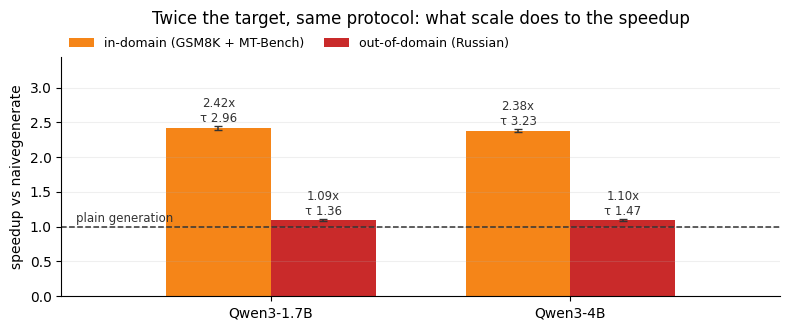

In [34]:
# --- Scaling figure ----------------------------------------------------------------
if SCALE_SWEEP:
    labels = ["Qwen3-1.7B", "Qwen3-4B"]
    x = np.arange(2); w = 0.35
    fig, ax = plt.subplots(figsize=(8.0, 3.4))
    sp_in  = [SCALING["m17"]["in"]["speedup"],  SCALING["m4b"]["in"]["speedup"]]
    sp_out = [SCALING["m17"]["out"]["speedup"], SCALING["m4b"]["out"]["speedup"]]
    er_in  = [SCALING["m17"]["in"]["speedup_err"],  SCALING["m4b"]["in"]["speedup_err"]]
    er_out = [SCALING["m17"]["out"]["speedup_err"], SCALING["m4b"]["out"]["speedup_err"]]
    b1 = ax.bar(x - w/2, sp_in,  w, color=C_EAGLE, label="in-domain (GSM8K + MT-Bench)",
                yerr=er_in, capsize=3, ecolor=C_INK, error_kw=dict(lw=1.1))
    b2 = ax.bar(x + w/2, sp_out, w, color="#C92A2A", label="out-of-domain (Russian)",
                yerr=er_out, capsize=3, ecolor=C_INK, error_kw=dict(lw=1.1))
    for bars, key, errs in ((b1, "in", er_in), (b2, "out", er_out)):
        for i, b in enumerate(bars):
            m = SCALING["m17" if i == 0 else "m4b"][key]
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + errs[i] + 0.06,
                    f"{m['speedup']:.2f}x\nτ {m['tau']:.2f}", ha="center", fontsize=8.5, color=C_INK)
    ax.axhline(1.0, color=C_INK, lw=1.1, ls="--")
    ax.set_xlim(-0.7, 1.7)
    ax.text(-0.65, 1.03, "plain generation", fontsize=8.5, color=C_INK, va="bottom")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("speedup vs naivegenerate")
    ax.set_ylim(0, max(sp_in) * 1.42)     # запас под легенду, вынесенную над осями
    ax.set_title("Twice the target, same protocol: what scale does to the speedup", pad=24)
    # одной строкой НАД осями: в углу её вторая строка ложилась на подпись столбика
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="lower left",
              bbox_to_anchor=(0.0, 1.0), borderaxespad=0.2, columnspacing=1.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
    finish("scaling")


> **Takeaway.** Two targets, one protocol, and the prediction only half survives. Acceptance length does rise with target size, and by a remarkably stable amount: about 9% higher on the 4B pair, in domain and out, on every full run of this notebook — including runs where [§7](#s7) settled on a different tree and every absolute number shifted with it. Greedy decoding fixes the token sequence, so within a run the three repeats return the same acceptance length to three decimals; the whiskers in the figure above are pure timing jitter. The speedup does not follow, and *how* it fails to follow is the interesting part: across those runs the 4B pair landed anywhere within about 3% either way, the sign changing from run to run. The quantity that reproduces says the draft head got better; the quantity that drifts cannot tell whether anything changed at all. Doubling the target bought acceptance length and, as far as this card can resolve, no speed.

The mechanism is in the raw timings rather than the ratios, and it needs the cycle and the token kept apart. An ordinary step gets dearer on the bigger target, and a full speculative cycle — one round of drafting plus one tree verification — gets dearer faster still, on every run: verification carries the same widened weights the step does, while drafting is no longer free. The 9% extra tokens each cycle returns then buys back almost exactly that difference. What survives the cancellation is the couple of percent above, which is the same size as the drift between runs — hence the moving sign. The cell's output prints the run's own figures; the relation between them is what holds.

So it is the premise that fails: a draft head is not fixed in cost. This one grew with its target, from 137M parameters to 218M, because its hidden size and attention widen alongside the model. It does shrink as a share of the target, from 8.0% to 5.4%, but share is not what the formula's denominator charges for — absolute draft time is.

The out-of-domain bars point at the other open question without closing it. Neither pair falls below 1.0 here, on any run — so the win itself is not in doubt. What is in doubt is the cause. This subset differs from [§5](#s5)'s in more than the tree shape — fewer prompts, a shorter budget — so on its own it cannot say which of those changes lifted the Russian set from 0.95× to above 1.0. One thing it can say: acceptance length barely moved between the two, so the shorter subset is not an easier one, and what changed is the price of the cycle; how often the draft is right stayed put. That points at tree depth, and [§7](#s7) tests the guess directly: it sweeps depth on the Russian set too, and the curve crosses 1.0 while acceptance length holds near one and a half throughout. What the run does support is the ordering: domain sets how much speculation can win, tree shape sets how much it can lose.

In [35]:
import json as _json

try:
    _keys = {
        "overall": {"tau": float(overall_tau),
                    "speedup_naive": float(overall_sp),
                    "speedup_hf": float(bench_df.speedup_hf.mean())},
        "in_domain": {"tau": float(in_dom.tau.mean()),
                      "speedup": float(in_dom.speedup_naive.mean())},
        "out_of_domain": {"set": LANG_SET, "tau": float(out_dom.tau.mean()),
                          "speedup": float(out_dom.speedup_naive.mean())},
        "by_set": {b: {"tau": float(g.tau.mean()), "speedup": float(g.speedup_naive.mean())}
                   for b, g in bench_df.groupby("bench")},
        "branching": {"tau_tree": float(tau_tree), "tau_chain": float(tau_chain),
                      "gain_pct": float(100 * (tau_tree / tau_chain - 1))},
        "cycle_ms": dict({k: float(v) for k, v in parts.items()},
                         naive_step=float(NAIVE_MS), total=float(cycle_ms)),
        "temperature": {str(r["T"]): {"tau": float(r["tau"]), "speedup": float(r["speedup"])}
                        for r in temp_rows},
        "tree": dict(MAIN_TREE),
        # §5 quotes a percentage derived from these sweeps; without them in the dump
        # it is the one load-bearing number the reconciler cannot check
        # §6 quotes these shares by hand; same reason as the ablation block
        # numbers the prose leans on that were not in the dump before
        "roofline": {"free_upto": int(free_upto), "step_ms": float(step_ms),
                     "predicted_ms": float(predicted_ms), "mbu": float(mbu)},
        "break_even": float(tau_break),
        "cycle_tau": float(inst["tokens"] / inst["steps"]),
        "divergence": {"n_diffs": len(diffs),
                       "background_median": float(np.median(background))},
        "acceptance": {"alpha": [float(a) for a in alpha],
                       "max_accept_length": int(max(s["accept_length"] for s in trace)),
                       "n_cycles": len(trace)},
        "ablation": {"naive_ms": float(NAIVE_MS), "naive_ms_ru": float(NAIVE_RU),
                     "depth": {str(k): {"ms": float(v["ms"]), "tau": float(v["tau"])}
                               for k, v in depth_res.items()},
                     "depth_ru": {str(k): {"ms": float(v["ms"]), "tau": float(v["tau"])}
                                  for k, v in depth_ru.items()},
                     "size": {str(k): {"ms": float(v["ms"]), "tau": float(v["tau"])}
                              for k, v in size_res.items()}},
        "scaling": globals().get("SCALING"),
    }
    with open("/kaggle/working/key_numbers.json", "w") as _f:
        _json.dump(_keys, _f, ensure_ascii=False, indent=1)
except Exception as _e:                      # reconciliation must never kill the run
    print("!! key-number summary FAILED, prose cannot be reconciled:", repr(_e))
else:
    print(f"key_numbers.json written ({len(_keys)} groups, scaling: "
          f"{'yes' if _keys['scaling'] else 'no'})")


key_numbers.json written (15 groups, scaling: yes)


<a id="dead-ends"></a>
## 12. What didn't work

Dead ends and traps that cost time, listed so they are not repeated.

**P100 instead of T4.** Kaggle's default under `enable_gpu` is a P100, and the preinstalled `torch 2.10+cu128` does not support `sm_60`: it dies with `CUDA error: no kernel image is available`. The fix is picking a T4 (via the API, `machine_shape: NvidiaTeslaT4`).

**Installing the repo through pip.** EAGLE's `setup.py` pulls `torch==2.0.1` and `transformers==4.46.2`, which wrecks a fresh environment. The right path: clone, add to `sys.path`, and pin `transformers` separately (`4.53.1`; the preinstalled 5.x is incompatible with the repo's modified modeling files).

**The deep default tree.** The starting shape `60/7/10` and the authors' `32/8/4` share one trait: depth 7 and 8. The [§7](#s7) sweep shows depth does not pay on this card — acceptance plateaus by level four while every level bills. I did not measure `32/8/4` itself: the [§7](#s7) depth sweep moves depth at fixed `total_token` and `top_k`, touching one knob of three, so I quote no numbers for that exact shape — the conclusion is about depth, not one configuration.

**Chasing percent-level differences.** An early version picked its configuration on 2.42× vs 2.43× from a single run per point. Repeats showed about a percent of run-to-run spread: the difference was noise. Hence the repeats (three per point) and whiskers on every plot.

**Growing the tree forever.** τ keeps rising past 96 nodes; speed does not — the gain is eaten by the cost of building the tree itself. The bottleneck migrates from verification to the draft model.

**A bootstrap null band.** The first T = 1 test built its null band by resampling the observed sample. On a sparse support this systematically understates the band: a bootstrap draws from a pool of a few hundred values and produces more coincidences than two truly independent draws. The test confidently declared a difference where none exists. A permutation test does not have this problem, and the plain-vs-plain control catches the failure instantly: on the broken test the control showed a difference too.

**Chasing low per-position p-values.** Even with a sound test, two positions of five came back with p < 0.05. Tempting to declare the guarantee broken, but with ten comparisons (five positions, two tests each) at α = 0.05 the expectation is half a false positive on average, so p-values alone do not settle it. For position 0 a direct measurement did: the distributions match bit for bit, leaving the difference nowhere to come from. For later positions a direct comparison is impossible in principle, since the distribution there depends on the already-sampled prefix, which each run grows on its own. So those p-values go down to multiple comparisons: nothing further is provable here.

**The official loader rejects the 4B head.** `AngelSlim/Qwen3-4B_eagle3` is listed in the official weights table, yet `EaModel.from_pretrained` dies on it with state-dict size mismatches: the head was trained with `head_dim = 128` at 32 heads (attention width 4096, hidden 2560 — the modern Qwen3 layout), and the official `cnets.py` hardcodes `head_dim = hidden // heads`. True on the pinned commit and on current `main`. The three-line fix lives in the environment cell; without it, only AngelSlim's own framework or vLLM can run this head.

**Testing the distribution on a "convenient" prompt.** The first attempt to check distribution invariance at T = 1 used a prompt whose continuation is nearly deterministic: TV came out exactly 0 against a null band of [0, 0]. Formally a match; substantively, the test checked nothing. The prompt needs real entropy, or emptiness is being verified.


<a id="takeaways"></a>
## 13. Takeaways

1. **Speculative decoding works because decoding is memory-bound.** On a T4 the target pass barely gets dearer up to about 192 tokens, so verifying a whole tree costs about what generating one token costs. Everything else in the method is an attempt to pack more accepted tokens into that single pass.
2. **Speedup is set by acceptance length, and acceptance length by domain and tree shape together.** The same draft head spans two-and-a-half-fold gains on math and code down to an outright slowdown on Russian prompts — but that slowdown is measured at the deep starting tree. At the shape [§7](#s7) picks, the same prompts land above 1.0 at practically the same acceptance length, and [§11](#scaling) sees the same on a second pair of models. Domain sets how much the method can win; tree depth sets how much it can lose. Measure acceptance length on your own prompt distribution; other people's numbers do not transfer.
3. **Tree width is cheaper than depth.** Width adds nodes to the same verification pass; depth adds new sequential draft-model launches. Meanwhile the authors' auto-pick heuristic tunes node count and never turns the depth knob at all.
4. **The method does not spoil the output, verifiably in three ways.** At T = 0 the output matches token for token, and the rare divergences land strictly on positions where two candidates are nearly tied in logit: the gap there is indistinguishable from zero against a typical 2.8 logits. At T = 1 a permutation test does not reject equality of distributions, and a plain-vs-plain control shows the test finds no gap where none can exist — on the earlier, broken test that same control showed one. The third way is direct comparison: the distribution both loops draw their first token from matches bit for bit. Later positions cannot be compared this way — their distribution depends on a prefix each run grows on its own.
5. **Claimed speedups must always be read together with their baseline.** The plain step here runs at a quarter of the memory bandwidth; part of the measured gain amortizes that overhead rather than beating the memory wall. On a tuned stack the same method yields less — exactly why independent vLLM measurements are more modest than the authors'.

6. **Scale buys acceptance length, not speed — at least across this step.** The intuition that a bigger target amortizes the draft head better is checkable, and [§11](#scaling) checks it on Qwen3-4B: τ rises about 9% and the speedup does not move outside the noise, because this head family grows with its target instead of staying fixed. Whether the trend resumes at 8B and beyond is open — that pair does not fit a free T4 in fp16.

**What is not here.** Batches above one (the repository implementation only does batch = 1, and batching is what erodes speculation most), long contexts, and training your own head for your domain. The last is the most interesting follow-up, given point 2.


<a id="use-it"></a>
## 14. Run it yourself, further reading, licenses

Fork the notebook and change two of the four lines described in [§0](#s0):

```python
BASE_MODEL = "Qwen/Qwen3-4B"                 # any target model that has a head
EA_MODEL   = "AngelSlim/Qwen3-4B_eagle3"     # heads are listed in the EAGLE README
```

On size, since the example above is the case that hits it. [§5](#s5) loads a second,
independent copy of the target alongside the EAGLE pair to time the stock `generate`, so the
two-line fork is validated up to roughly 2B on a T4. The 4B pair alone takes most of the card
([§11](#scaling) prints the exact figure), and the extra copy does not fit on top: for a target this size, either drop the
stock-`generate` baseline in [§5](#s5) or unload the first pair before loading the second, the way [§11](#scaling) does.

To measure acceptance length on your own prompts (takeaway 2), add your set to the `BENCH` dict in [§5](#s5) — every table and figure downstream rebuilds around it. Where the break-even sits depends on the tree, so carry over the shape rather than the number: the [§5](#s5) plot fits it near one and a half tokens per cycle at that section's deep starting tree, while at the shallow tree [§7](#s7) settles on, [§11](#scaling) measured a small win at acceptance length about 1.5. What travels is the ordering [§11](#scaling) measured: domain sets how much speculation can win, tree shape sets how much it can lose. Whether a loss *requires* both is untested — the one run at the shallow tree also changed the prompt set and the budget.

The cell below prints the current configuration and what is worth changing in it.

In [36]:
# The current configuration. Changed in the notebook's first cell.
print(f'BASE_MODEL = "{BASE_MODEL}"')
print(f'EA_MODEL   = "{EA_MODEL}"')
print(f'tree    = {MAIN_TREE}')
print(f'sets    = {list(BENCH)}')
print()
print("To run on your model: change the first two lines and Run All.")
print("To run on your tasks: add your own list to BENCH (§5).")


BASE_MODEL = "/kaggle/input/models/qwen-lm/qwen-3/transformers/1.7b/1"
EA_MODEL   = "/kaggle/input/models/georgymamarin/qwen3-1-7b-eagle3-draft-head/pytorch/fp16/1"
tree    = {'total_token': 64, 'depth': 2, 'top_k': 10}
sets    = ['MT-Bench', 'GSM8K', 'HumanEval', 'Alpaca', 'Russian']

To run on your model: change the first two lines and Run All.
To run on your tasks: add your own list to BENCH (§5).


### Further reading

**How the method reached its current form**

- [Leviathan et al., 2211.17192](https://arxiv.org/abs/2211.17192) — the original idea and the unbiasedness proof via rejection sampling; the proof itself sits in Appendix A.1 if you want to check it.
- [Chen et al., 2302.01318](https://arxiv.org/abs/2302.01318) — independent parallel work, worth reading for a second angle on the same proof.
- [EAGLE-1, 2401.15077](https://arxiv.org/abs/2401.15077) — why predicting a feature is easier than predicting a token.
- [EAGLE-2, 2406.16858](https://arxiv.org/abs/2406.16858) — the dynamic tree; `total_token`, `depth` and `top_k` from [§7](#s7) originate here.
- [EAGLE-3, 2503.01840](https://arxiv.org/abs/2503.01840) — the paper under study: dropping `l_fea`, three-level fusion, training-time test.
- [HASS, 2408.15766](https://arxiv.org/abs/2408.15766) — the closest ancestor of unrolling the draft on its own outputs during training.

**How it looks in production**

- ["Performance or Illusion?", 2601.11580](https://arxiv.org/abs/2601.11580) — an independent replication on vLLM. The main point: gains shrink as batch size grows, because batching keeps the compute units busy on its own, leaving nothing for speculation.

**Code and weights**

- [SafeAILab/EAGLE](https://github.com/SafeAILab/EAGLE) — the official implementation, commit `cb7e0841`, Apache 2.0. This notebook uses it as published, with the single three-line exception [§11](#scaling) documents; `eagle/model/cnets.py` (tree construction) and `eagle/model/utils.py` (verification and KV handling) are the files worth reading.
- [AngelSlim/Qwen3-1.7B_eagle3](https://huggingface.co/AngelSlim/Qwen3-1.7B_eagle3) — the draft head, trained by the [AngelSlim](https://github.com/Tencent/AngelSlim) team (Tencent), attached here as a [Kaggle model](https://www.kaggle.com/models/georgymamarin/qwen3-1-7b-eagle3-draft-head). Not the authors' own: the team's measurements report acceptance length 1.8–3.5, which matches mine; their 1.4–1.9× speedup is quoted against their own baseline.
- [Qwen/Qwen3-1.7B](https://huggingface.co/Qwen/Qwen3-1.7B) — the target model, Apache 2.0, attached from the official [Qwen 3 Kaggle page](https://www.kaggle.com/models/qwen-lm/qwen-3).
- The question sets (MT-Bench, GSM8K, HumanEval, Alpaca) come from the same repository's `eagle/data` — the very sets the paper reports on.

*Прочесть этот разбор по-русски: [русская версия](https://www.kaggle.com/code/georgymamarin/eagle-3-qwen3-1-7b-speculative-decoding) — исходный ноутбук, сделанный для отбора Школы анализа данных.*

---

### Author and credits

Written by [Georgy Mamarin](https://www.kaggle.com/georgymamarin): the questions, the measurements, the notebook code and the text. The method, the implementation, the draft-head weights and the question sets belong to the authors listed above.

Particular thanks to the [SafeAILab](https://github.com/SafeAILab/EAGLE) team, whose open implementation this walkthrough runs as published, save for the three lines [§11](#scaling) needs to load a head with a modern `head_dim` and documents in place; to the [AngelSlim](https://huggingface.co/AngelSlim/Qwen3-1.7B_eagle3) team at Tencent for the public draft heads for Qwen3-1.7B and Qwen3-4B; and to Kaggle for the free T4 everything here was computed on.

The notebook's code is Apache 2.0; models and weights keep their own licenses.

If you reproduce this on another model or catch a measurement error, say so in the comments — both are equally useful news.
